# Assignment 2: Telecom Churn Prediction

In this notebook we build, tune, compare, and export three tabular classification models for telecom churn prediction.
The two main Assignment 2 models are **XGBoost** and a **PyTorch MLP with categorical embeddings**, while **RandomForestClassifier** is kept only as a baseline reference in the final comparison table.

The workflow is designed to be professional and leakage-aware.
Training happens on the training split, hyperparameter tuning and model selection happen on the validation split, and final selected model results are reported on the untouched test split.

The notebook is also designed to be **Colab-friendly**.
The primary data-ingestion path uses Kaggle with `kaggle.json`, so students can run the notebook top to bottom without manually debugging dataset paths.


## Notebook Helper Setup

We start with a very small helper/setup cell.
Its job is only to make notebook rendering cleaner and to define a few shared display constants that later cells can reuse.

The next code cell should finish quickly and simply confirm that the notebook helper layer is ready.


In [ ]:
# Lightweight notebook setup.
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

DEFAULT_FIGSIZE = (8, 5)
OPTIONAL_SECTIONS_LABEL = "Optional Professional Addition"

print("Notebook helpers loaded!")


Notebook helpers loaded!


## Imports, Package Availability, And Reproducibility

Before we load data or train models, we make sure the notebook environment has the required libraries.
This cell also sets random seeds so that the training and tuning steps are more reproducible.

The next code cell should:
- install any missing packages in a practical way for Colab or local execution
- import the core libraries used throughout the notebook
- configure warnings, plotting style, and random seeds


In [ ]:
import importlib
import json
import math
import os
import random
import re
import shutil
import sys
import warnings
from copy import deepcopy
from pathlib import Path

REQUIRED_PACKAGES = {
    "joblib": "joblib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "xgboost": "xgboost",
    "shap": "shap",
    "kaggle": "kaggle",
}

missing_packages = [
    pip_name
    for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    get_ipython().system("pip install -q " + " ".join(missing_packages))
else:
    print("All required packages are already available.")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

IS_COLAB = "google.colab" in sys.modules

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Running in Colab: {IS_COLAB}")


All required packages are already available.
Python version: 3.12.13
PyTorch version: 2.10.0+cu128
CUDA available: True
Running in Colab: True


## Runtime Configuration

This cell defines the high-level runtime settings for the notebook.
That includes the Kaggle dataset slug, the extraction directory inside `/content/`, the target-column candidates, the split proportions, and the export directory for deployment artifacts.

We also keep a manual `DATA_FILE` option as a **secondary fallback only**.
The normal path should be Kaggle-based ingestion handled in the next section.


In [ ]:
DATA_FILE = None  # Fallback only. Example: Path("/content/Telco-Customer-Churn.csv")
KAGGLE_DATASET = "blastchar/telco-customer-churn"
KAGGLE_DOWNLOAD_DIR = Path("/content")
KAGGLE_EXTRACT_DIR = KAGGLE_DOWNLOAD_DIR / "telco_churn_kaggle"
TARGET_COLUMN_CANDIDATES = ["churn", "exited", "target", "left_company"]
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.25
EXPORT_DIR = Path("exported_artifacts")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Kaggle dataset: {KAGGLE_DATASET}")
print(f"Kaggle extraction directory: {KAGGLE_EXTRACT_DIR}")
print(f"Export directory: {EXPORT_DIR.resolve()}")


Kaggle dataset: blastchar/telco-customer-churn
Kaggle extraction directory: /content/telco_churn_kaggle
Export directory: /content/exported_artifacts


## Colab Upload Step For `kaggle.json`

Kaggle is the primary dataset source for this notebook.
In Colab, the most practical workflow is to upload `kaggle.json` once near the top, then let the notebook configure credentials, download the dataset, extract it, and continue automatically.

The next code cell is the dedicated Colab upload helper.
Use it when `kaggle.json` is not already present in `/content/` or `~/.kaggle/`.
If you are running outside Colab and already have `~/.kaggle/kaggle.json`, you can skip the upload interaction and continue.


In [ ]:
uploaded_kaggle_json = None
kaggle_json_candidates = [
    Path("/content/kaggle.json"),
    Path("kaggle.json"),
    Path.home() / ".kaggle" / "kaggle.json",
]
existing_kaggle_json = next((candidate for candidate in kaggle_json_candidates if candidate.exists()), None)

if existing_kaggle_json is not None:
    print(f"Existing kaggle.json detected at: {existing_kaggle_json}")
elif IS_COLAB:
    try:
        from google.colab import files

        print("Upload your kaggle.json file now.")
        uploaded = files.upload()
        if "kaggle.json" in uploaded:
            uploaded_kaggle_json = Path("/content/kaggle.json")
            print(f"Uploaded kaggle.json to: {uploaded_kaggle_json}")
        elif uploaded:
            print("A file was uploaded, but it was not named 'kaggle.json'.")
        else:
            print("No file was uploaded.")
    except Exception as error:
        print(f"Colab upload helper could not run: {error}")
else:
    print("Not running in Colab. Skipping the upload helper.")
    print("Use ~/.kaggle/kaggle.json or set DATA_FILE manually as a fallback.")


Upload your kaggle.json file now.


Saving kaggle.json to kaggle.json
Uploaded kaggle.json to: /content/kaggle.json


## Kaggle Dataset Setup

This is the main ingestion step for the notebook.
We configure Kaggle credentials from `kaggle.json`, download the telecom churn dataset, extract it into `/content/telco_churn_kaggle`, automatically locate the CSV file, and then assign that file to `DATA_FILE`.

Why this matters:
- it keeps the notebook runnable end to end in Colab
- it avoids manual path debugging
- it makes the source dataset explicit and reproducible

The next code cell should produce one of two outcomes:
- a resolved `DATA_FILE` path from the Kaggle workflow, which is the preferred path
- or a clearly reported fallback to manual `DATA_FILE` if Kaggle credentials are not available


In [ ]:
from pathlib import Path
import os
import shutil
import zipfile

def resolve_kaggle_json_path() -> Path | None:
    candidate_paths = [
        Path("/content/kaggle.json"),
        Path("kaggle.json"),
        Path.home() / ".kaggle" / "kaggle.json",
    ]
    return next((candidate for candidate in candidate_paths if candidate.exists()), None)


def configure_kaggle_credentials(kaggle_json_path: Path) -> Path:
    kaggle_target_dir = Path.home() / ".kaggle"
    kaggle_target_dir.mkdir(parents=True, exist_ok=True)
    kaggle_target_file = kaggle_target_dir / "kaggle.json"

    if kaggle_json_path.resolve() != kaggle_target_file.resolve():
        shutil.copy(kaggle_json_path, kaggle_target_file)

    kaggle_target_file.chmod(0o600)
    os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_target_dir)
    return kaggle_target_file


def discover_churn_csv(search_dir: Path) -> Path:
    csv_candidates = sorted(search_dir.rglob("*.csv"))
    if not csv_candidates:
        raise FileNotFoundError("Dataset download succeeded, but no CSV file was found in the extraction directory.")

    preferred_candidates = [
        candidate
        for candidate in csv_candidates
        if "churn" in candidate.name.lower() or "telco" in candidate.name.lower()
    ]
    return preferred_candidates[0] if preferred_candidates else csv_candidates[0]


resolved_data_file = None
kaggle_json_path = resolve_kaggle_json_path()

if kaggle_json_path is not None:
    configured_path = configure_kaggle_credentials(kaggle_json_path)
    print(f"Kaggle credentials configured at: {configured_path}")

    if KAGGLE_EXTRACT_DIR.exists():
        shutil.rmtree(KAGGLE_EXTRACT_DIR)
    KAGGLE_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    archive_path = KAGGLE_DOWNLOAD_DIR / "telco-customer-churn.zip"
    if archive_path.exists():
        archive_path.unlink()

    !kaggle datasets download -d {KAGGLE_DATASET} -p {KAGGLE_DOWNLOAD_DIR} --force

    with zipfile.ZipFile(archive_path, "r") as zip_ref:
        zip_ref.extractall(KAGGLE_EXTRACT_DIR)

    resolved_data_file = discover_churn_csv(KAGGLE_EXTRACT_DIR)
    print(f"Dataset CSV discovered at: {resolved_data_file}")

elif DATA_FILE is not None:
    resolved_data_file = Path(DATA_FILE)
    print(f"Using fallback DATA_FILE: {resolved_data_file}")

else:
    print("No Kaggle credentials were found and DATA_FILE is not set.")
    print("Provide kaggle.json and rerun this cell, or set DATA_FILE manually as the fallback path.")

if resolved_data_file is not None:
    DATA_FILE = Path(resolved_data_file)
    print(f"Resolved DATA_FILE: {DATA_FILE}")

Kaggle credentials configured at: /root/.kaggle/kaggle.json
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 272kB/s]

Dataset CSV discovered at: /content/telco_churn_kaggle/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolved DATA_FILE: /content/telco_churn_kaggle/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Reusable Helpers

Before we load the dataset into memory, we define the reusable helper functions that keep the rest of the notebook concise.
These helpers handle column-name cleanup, target coercion, summary tables, visual diagnostics, preprocessing support, and evaluation plots.

The next code cell should only define reusable functionality.
It should not perform modeling work yet.


In [ ]:
def make_safe_column_names(frame: pd.DataFrame) -> pd.DataFrame:
    renamed = {}
    for column in frame.columns:
        safe_name = re.sub(r"[^0-9a-zA-Z]+", "_", str(column).strip().lower()).strip("_")
        renamed[column] = safe_name
    return frame.rename(columns=renamed)


def load_dataframe(data_file: str | Path | None) -> pd.DataFrame:
    if data_file is None:
        raise FileNotFoundError(
            "No dataset file is configured. Run the Kaggle setup cell first, or set DATA_FILE manually as a fallback."
        )

    path = Path(data_file)
    if not path.exists():
        raise FileNotFoundError(f"Configured dataset path does not exist: {path}")
    print(f"Loading dataset from: {path}")
    return pd.read_csv(path)


def pick_target_column(frame: pd.DataFrame, preferred_names: list[str]) -> str:
    available = set(frame.columns)
    for candidate in preferred_names:
        if candidate in available:
            return candidate
    raise KeyError(f"Could not find a target column. Tried: {preferred_names}")


def coerce_binary_target(series: pd.Series) -> pd.Series:
    if series.dropna().nunique() == 2 and set(series.dropna().unique()).issubset({0, 1}):
        return series.astype(int)
    lowered = series.astype(str).str.strip().str.lower()
    positive_values = {"yes", "true", "1", "churn", "exited", "left", "positive"}
    negative_values = {"no", "false", "0", "not_churn", "stayed", "negative"}
    if set(lowered.dropna().unique()).issubset(positive_values | negative_values):
        return lowered.map(lambda value: 1 if value in positive_values else 0).astype(int)
    unique_values = sorted(series.dropna().unique())
    if len(unique_values) != 2:
        raise ValueError("Target column is not binary after inspection.")
    mapping = {unique_values[0]: 0, unique_values[1]: 1}
    print(f"Binary target mapping inferred as: {mapping}")
    return series.map(mapping).astype(int)


def summarize_dataframe(frame: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing_values": frame.isna().sum(),
        "missing_pct": frame.isna().mean().round(4),
        "n_unique": frame.nunique(dropna=False),
    })
    return summary.sort_values(["missing_values", "n_unique"], ascending=[False, False])


def display_target_distribution(target: pd.Series) -> None:
    counts = target.value_counts().sort_index()
    ax = counts.plot(kind="bar", color=["#4c78a8", "#f58518"], figsize=DEFAULT_FIGSIZE)
    ax.set_title("Target Distribution")
    ax.set_xlabel("Churn Label")
    ax.set_ylabel("Count")
    ax.set_xticklabels(["No Churn", "Churn"], rotation=0)
    plt.show()


def plot_numeric_distributions(frame: pd.DataFrame, numeric_features: list[str], target: pd.Series, max_features: int = 4) -> None:
    selected = numeric_features[:max_features]
    if not selected:
        print("No numeric features available for plotting.")
        return
    plot_frame = frame[selected].copy()
    plot_frame["target"] = target.values
    fig, axes = plt.subplots(len(selected), 1, figsize=(9, 4 * len(selected)))
    if len(selected) == 1:
        axes = [axes]
    for axis, feature in zip(axes, selected):
        sns.histplot(data=plot_frame, x=feature, hue="target", kde=True, stat="density", common_norm=False, ax=axis)
        axis.set_title(f"Distribution of {feature} by churn")
        axis.set_xlabel(feature)
        axis.set_ylabel("Density")
    plt.tight_layout()
    plt.show()


def plot_categorical_churn(frame: pd.DataFrame, categorical_features: list[str], target: pd.Series, max_features: int = 4) -> None:
    selected = categorical_features[:max_features]
    if not selected:
        print("No categorical features available for plotting.")
        return
    plot_frame = frame[selected].copy()
    plot_frame["target"] = target.values
    fig, axes = plt.subplots(len(selected), 1, figsize=(10, 4 * len(selected)))
    if len(selected) == 1:
        axes = [axes]
    for axis, feature in zip(axes, selected):
        temp = plot_frame.groupby(feature, dropna=False)["target"].mean().sort_values(ascending=False).head(10)
        temp.plot(kind="bar", ax=axis, color="#72b7b2")
        axis.set_title(f"Average churn rate by {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Mean churn rate")
    plt.tight_layout()
    plt.show()


def build_tree_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, numeric_features), ("cat", categorical_pipeline, categorical_features)],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def get_feature_names_from_preprocessor(preprocessor: ColumnTransformer) -> list[str]:
    if hasattr(preprocessor, "get_feature_names_out"):
        return list(preprocessor.get_feature_names_out())
    return []


def evaluate_predictions(y_true: np.ndarray, probabilities: np.ndarray, threshold: float = 0.50) -> dict:
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }


def metrics_to_frame(metric_dict: dict[str, float], split_name: str) -> pd.DataFrame:
    return pd.DataFrame([{**{"split": split_name}, **metric_dict}])


def show_confusion_matrix(y_true: np.ndarray, probabilities: np.ndarray, threshold: float = 0.50, title: str = "Confusion Matrix") -> None:
    predictions = (probabilities >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()


def show_roc_curve(y_true: np.ndarray, probabilities: np.ndarray, title: str = "ROC Curve") -> None:
    fpr, tpr, _ = roc_curve(y_true, probabilities)
    auc_value = roc_auc_score(y_true, probabilities)
    plt.figure(figsize=DEFAULT_FIGSIZE)
    plt.plot(fpr, tpr, label=f"ROC AUC = {auc_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


## Dataset Loading

The data-ingestion section above should already have resolved `DATA_FILE`.
This cell now performs the clean handoff from ingestion to analysis: load the CSV, normalize the column names, identify the target, and confirm the dataset shape and class balance.

If the dataset path is still unresolved at this point, that means the Kaggle step or the fallback path needs attention before the modeling workflow can continue.


In [ ]:
# Data loading and cleaning happen before feature typing.
df = load_dataframe(DATA_FILE)
df = make_safe_column_names(df)
df["totalcharges"] = df["totalcharges"].astype(str).str.strip()
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")
target_column = pick_target_column(df, TARGET_COLUMN_CANDIDATES)
df[target_column] = coerce_binary_target(df[target_column])

display(df.head())
print(f"Dataset shape: {df.shape}")
print(f"Target column: {target_column}")
print(f"Target distribution: {df[target_column].value_counts(normalize=True).round(3).to_dict()}")


Loading dataset from: /content/telco_churn_kaggle/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Dataset shape: (7043, 21)
Target column: churn
Target distribution: {0: 0.735, 1: 0.265}


## Exploratory Data Analysis

Before modeling, we need to understand what kind of data we have, how much missingness we are dealing with, whether the target is imbalanced, and what kinds of features will need special handling.
The next cell prints a compact diagnostic summary that we will use to guide preprocessing choices.


In [ ]:
display(Markdown("### Data preview"))
display(df.head())
display(Markdown("### DataFrame info"))
df.info()
display(Markdown("### Missing-value and uniqueness summary"))
display(summarize_dataframe(df).head(20))

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")
print(f"Target balance: {df[target_column].value_counts().to_dict()}")


### Data preview

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### DataFrame info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


### Missing-value and uniqueness summary

,dtype,missing_values,missing_pct,n_unique
totalcharges,float64,11,0.0016,6531
customerid,object,0,0.0000,7043
monthlycharges,float64,0,0.0000,1585
tenure,int64,0,0.0000,73
paymentmethod,object,0,0.0000,4
multiplelines,object,0,0.0000,3
internetservice,object,0,0.0000,3
onlinesecurity,object,0,0.0000,3
onlinebackup,object,0,0.0000,3
deviceprotection,object,0,0.0000,3


Duplicate rows: 0
Target balance: {0: 5174, 1: 1869}


## Visual Exploration

Numeric and categorical features usually tell different stories in churn data.
The next code cell creates a focused set of plots so we can see the dataset before we commit to preprocessing and model tuning.


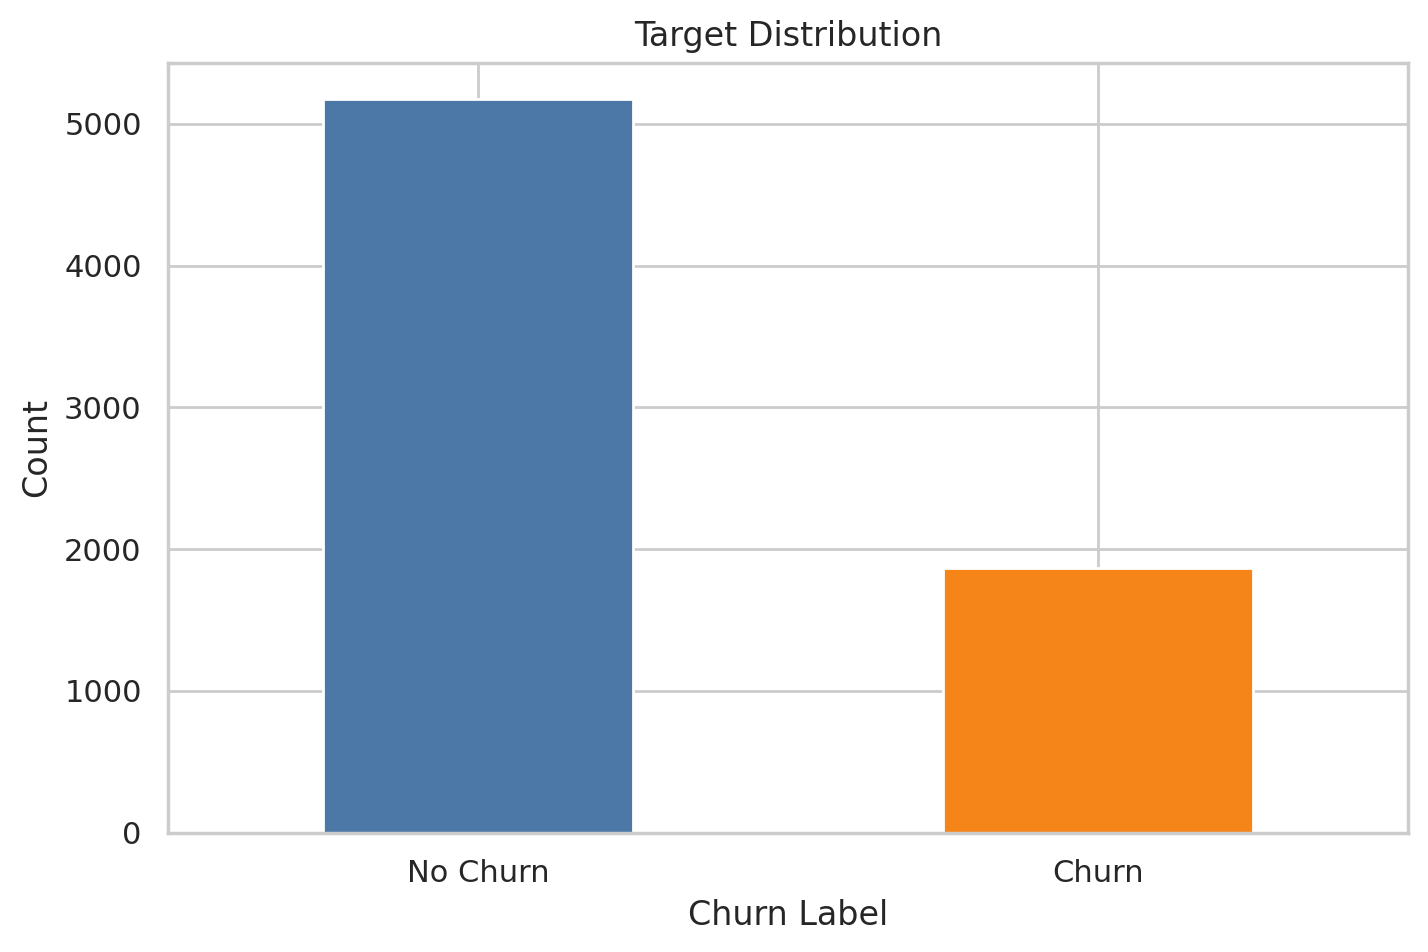

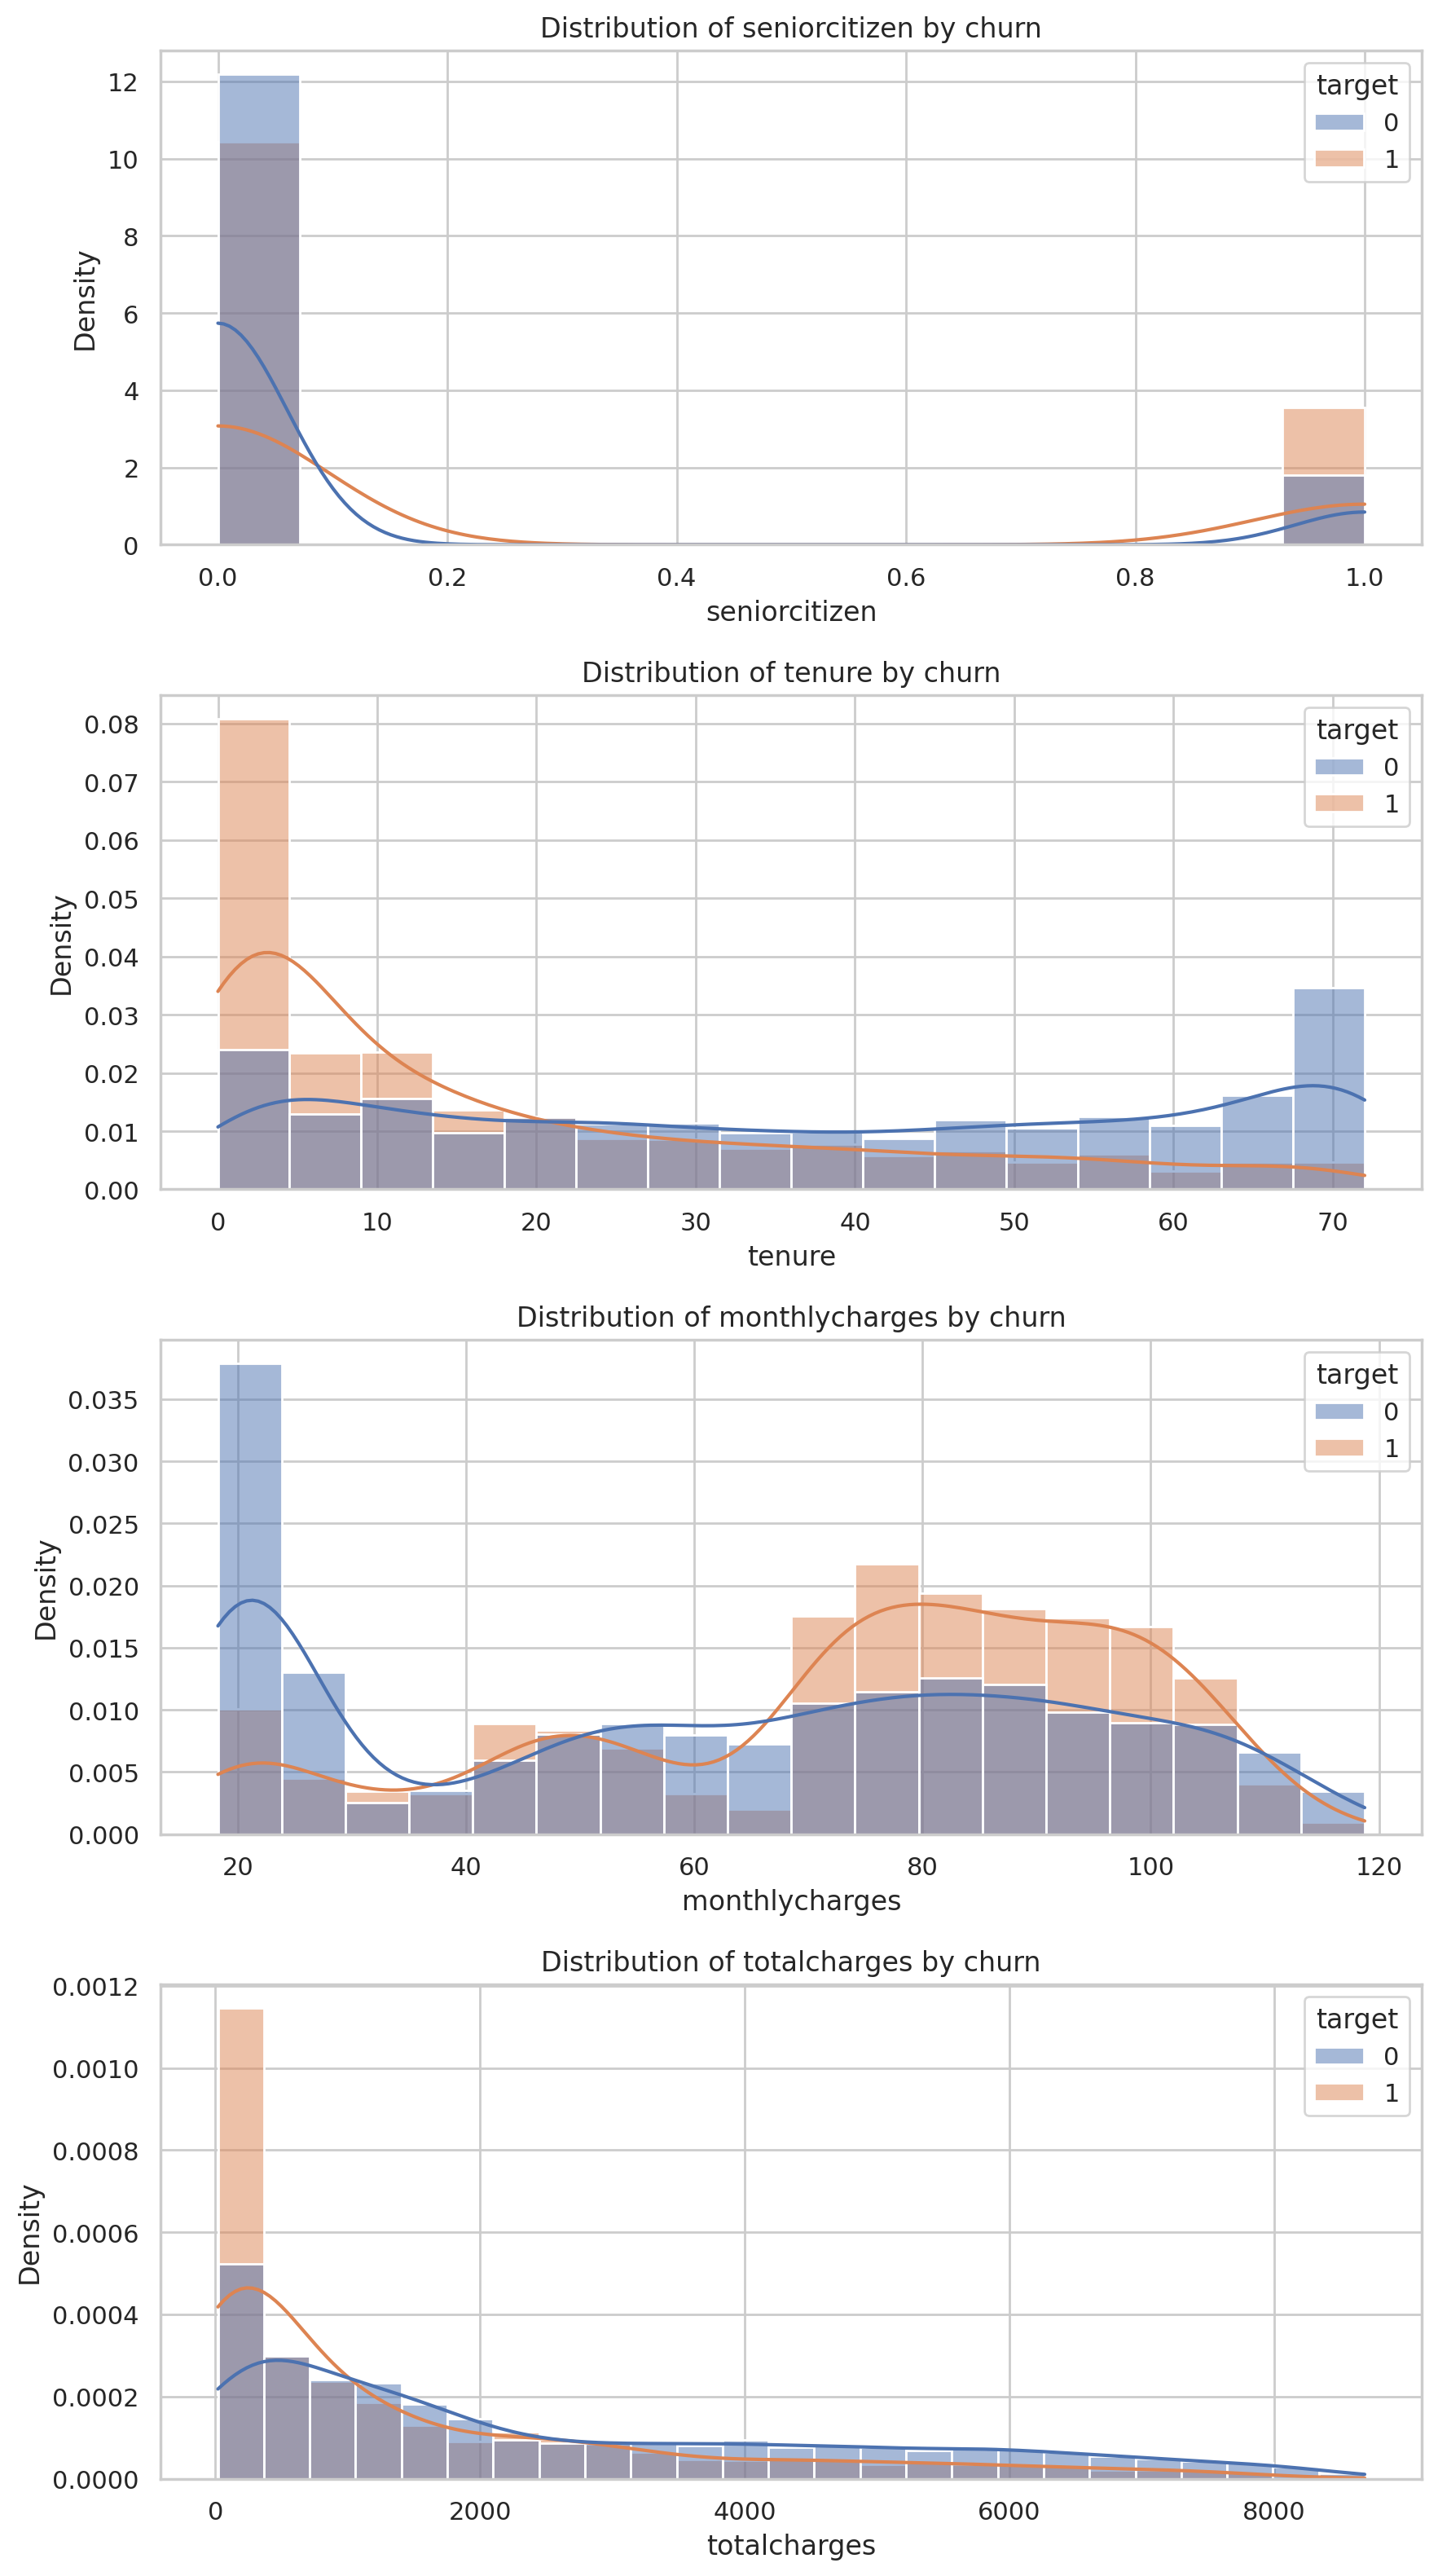

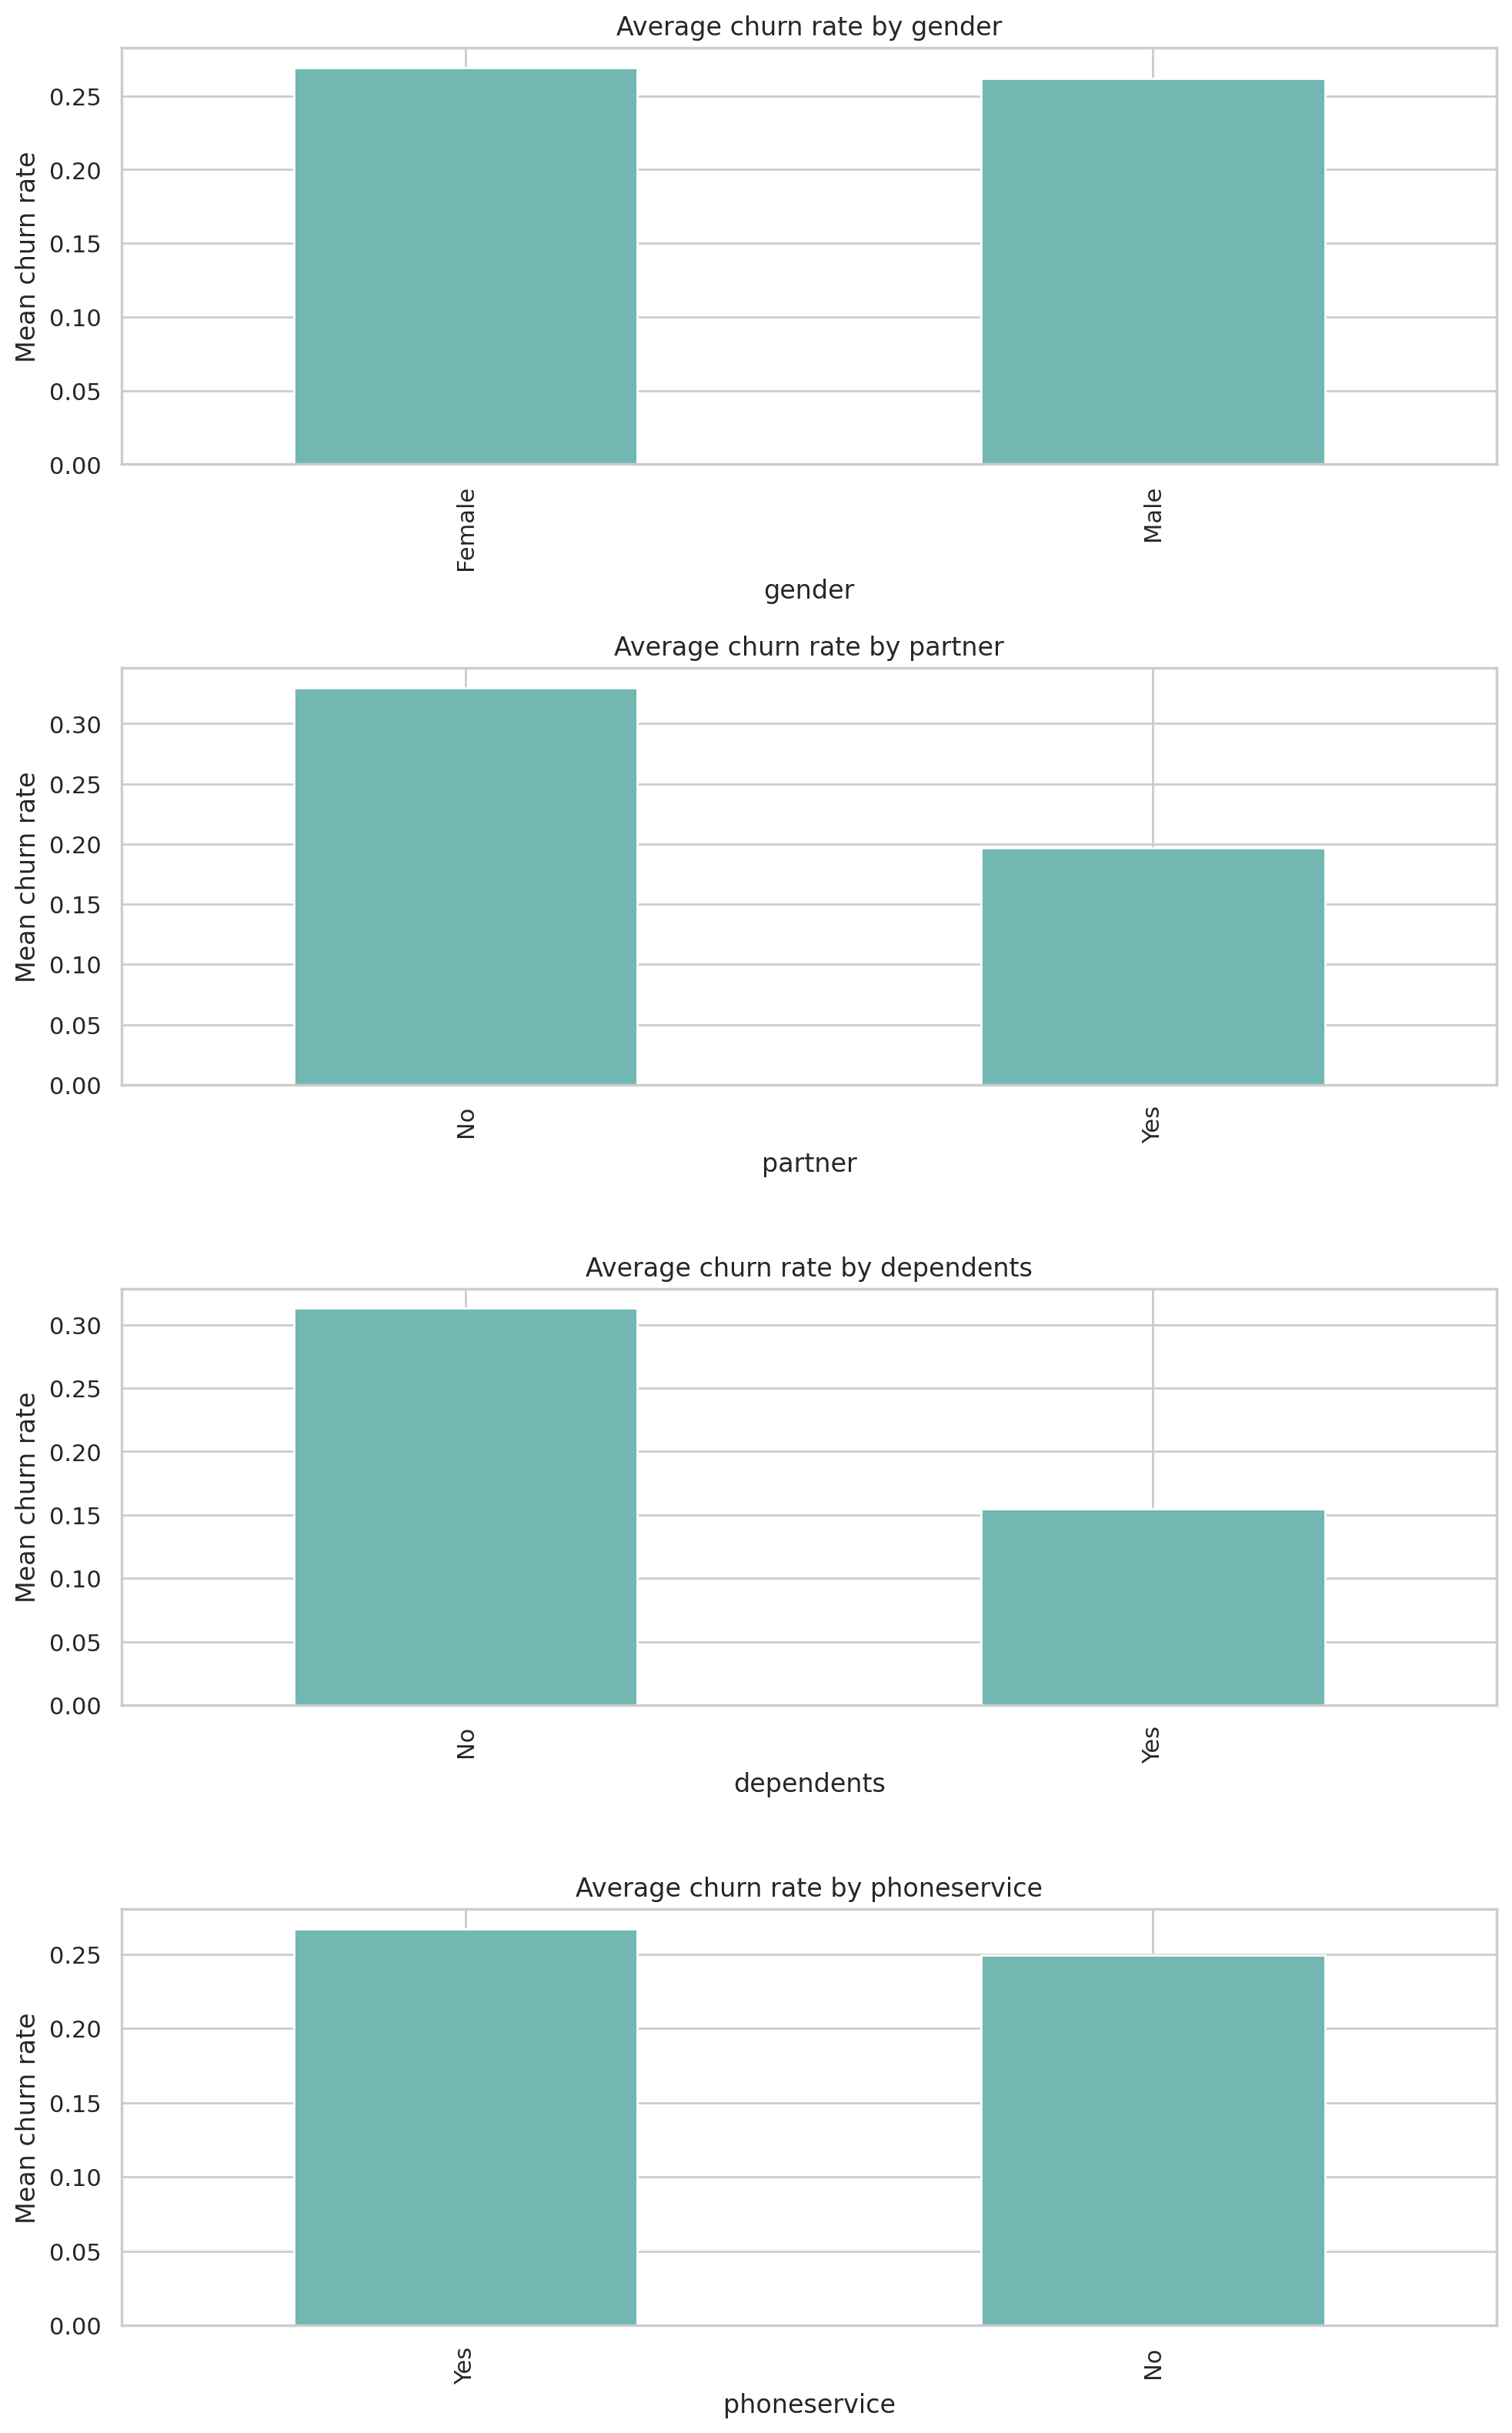

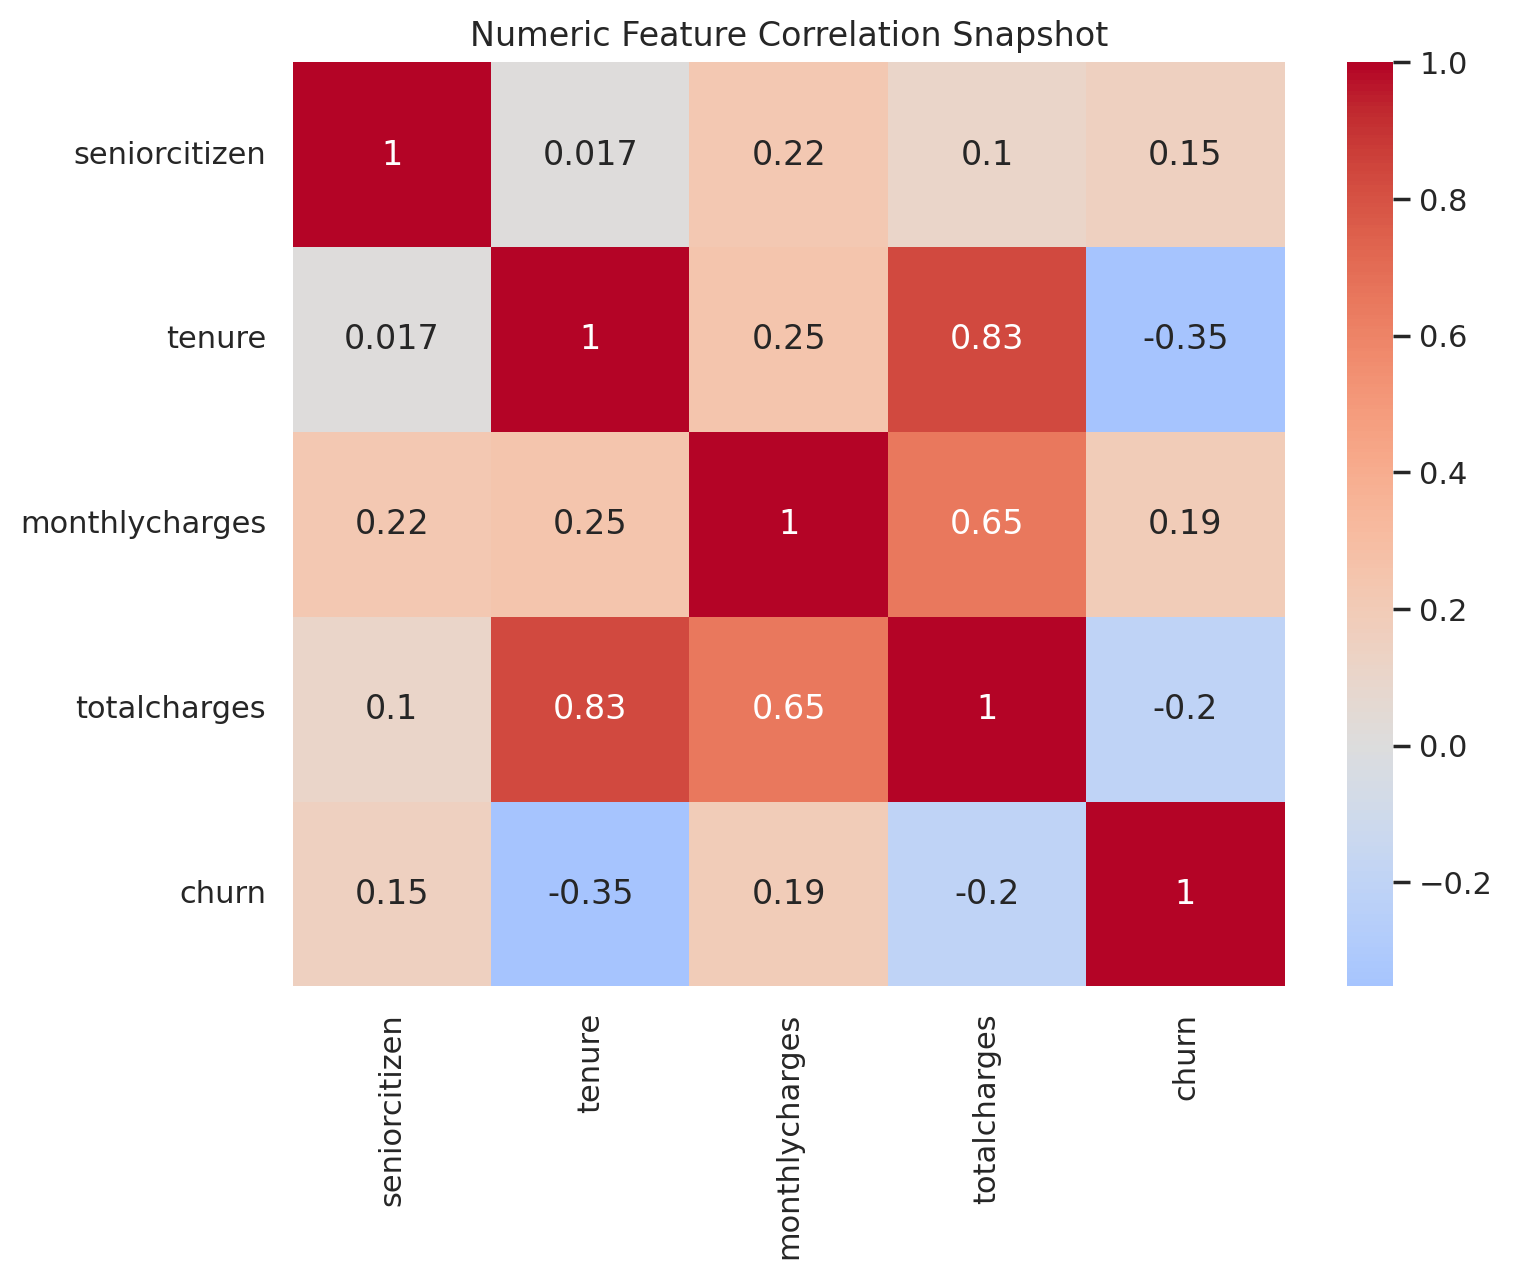

In [ ]:
drop_candidates = [column for column in df.columns if column in {target_column, "customerid", "customer_id", "id"}]
candidate_features = [column for column in df.columns if column not in drop_candidates]
numeric_preview = [column for column in candidate_features if pd.api.types.is_numeric_dtype(df[column])]
categorical_preview = [column for column in candidate_features if column not in numeric_preview]

display_target_distribution(df[target_column])
plot_numeric_distributions(df[candidate_features], numeric_preview, df[target_column], max_features=4)
plot_categorical_churn(df[candidate_features], categorical_preview, df[target_column], max_features=4)

if numeric_preview:
    corr_features = numeric_preview[:8]
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[corr_features + [target_column]].corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
    plt.title("Numeric Feature Correlation Snapshot")
    plt.show()


## Train, Validation, And Test Split

To keep the workflow leakage-safe, we split the data before fitting preprocessing objects or models.
The train split is used for fitting, the validation split is used for hyperparameter tuning and model selection, and the test split stays untouched until final reporting.


In [ ]:
# Feature typing happens once here and is reused by all downstream preprocessing/export steps.
# Split creation is reproducible via RANDOM_SEED and keeps the test set untouched for tuning.
drop_columns = [column for column in df.columns if column in {target_column, "customerid", "customer_id", "id"}]
feature_columns = [column for column in df.columns if column not in drop_columns]
X = df[feature_columns].copy()
y = df[target_column].astype(int).copy()

categorical_features = [
    column for column in feature_columns
    if pd.api.types.is_object_dtype(X[column]) or pd.api.types.is_categorical_dtype(X[column]) or pd.api.types.is_bool_dtype(X[column])
]
numeric_features = [column for column in feature_columns if column not in categorical_features]

for feature in categorical_features:
    X[feature] = X[feature].astype("string")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VALIDATION_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_SEED,
    stratify=y_train_val,
)

schema_summary = pd.DataFrame({
    "feature": feature_columns,
    "feature_type": ["categorical" if feature in categorical_features else "numeric" for feature in feature_columns],
})
display(schema_summary.head(20))
print(f"Train shape: {X_train.shape}, churn rate: {y_train.mean():.3f}")
print(f"Validation shape: {X_val.shape}, churn rate: {y_val.mean():.3f}")
print(f"Test shape: {X_test.shape}, churn rate: {y_test.mean():.3f}")


,feature,feature_type
0,gender,categorical
1,seniorcitizen,numeric
2,partner,categorical
3,dependents,categorical
4,tenure,numeric
5,phoneservice,categorical
6,multiplelines,categorical
7,internetservice,categorical
8,onlinesecurity,categorical
9,onlinebackup,categorical


Train shape: (4225, 19), churn rate: 0.265
Validation shape: (1409, 19), churn rate: 0.265
Test shape: (1409, 19), churn rate: 0.265


## Preprocessing Strategy

We deliberately use different preprocessing paths for tree models and the neural model because their needs differ.
The tree models use median imputation for numeric features and ordinal encoding for categorical features, while the MLP will later use numeric scaling plus explicit category-to-index mappings for embeddings.


In [ ]:
# Tree preprocessing is fit on the training split and reused for validation/test transforms.
tree_preprocessor = build_tree_preprocessor(numeric_features, categorical_features)
X_train_tree = tree_preprocessor.fit_transform(X_train)
X_val_tree = tree_preprocessor.transform(X_val)
X_test_tree = tree_preprocessor.transform(X_test)

tree_feature_names = get_feature_names_from_preprocessor(tree_preprocessor)
if not tree_feature_names:
    tree_feature_names = numeric_features + categorical_features

print(f"Tree preprocessing output shape (train): {X_train_tree.shape}")
print(f"First 10 transformed feature names: {tree_feature_names[:10]}")


Tree preprocessing output shape (train): (4225, 19)
First 10 transformed feature names: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice']


## RandomForest Baseline

We begin with a RandomForest baseline because it gives us a sturdy reference point.
If the later XGBoost and MLP models cannot improve on this baseline in a meaningful way, that is still a useful finding.


In [ ]:
# Baseline model training section: RandomForest on tree-preprocessed training data.
random_forest_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
random_forest_model.fit(X_train_tree, y_train)
print("RandomForest baseline trained.")


RandomForest baseline trained.


## RandomForest Baseline Evaluation

Baselines are still evaluated carefully.
We use the validation split here because we are still in the model-comparison phase, and validation is the correct place to judge behavior before final reporting.


,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.792761,0.610811,0.604278,0.607527,0.828687


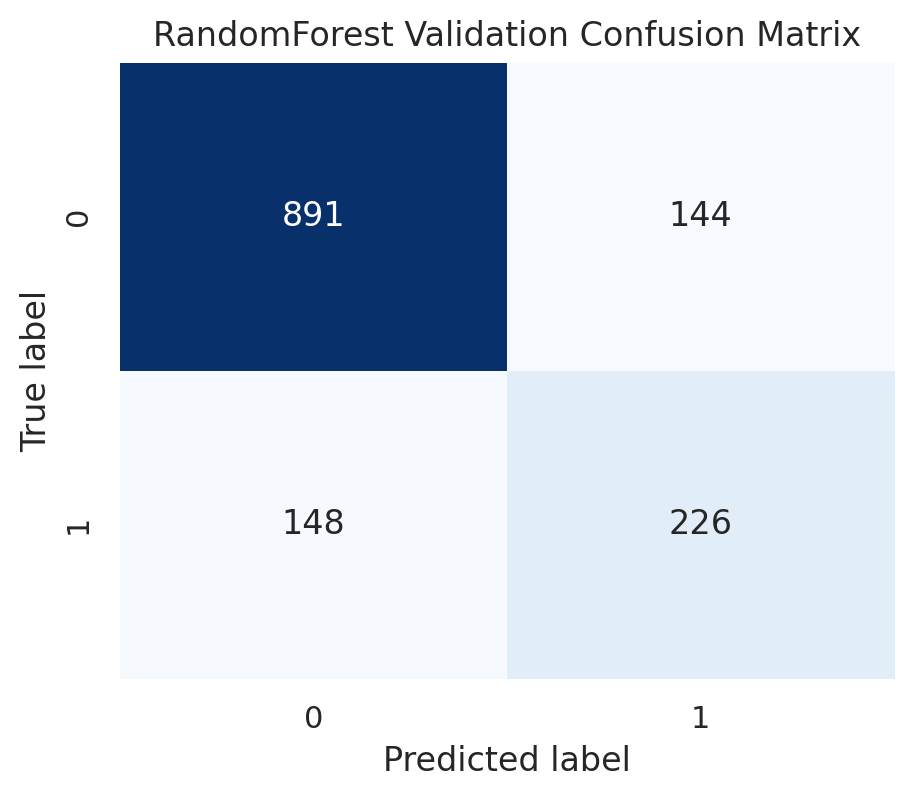

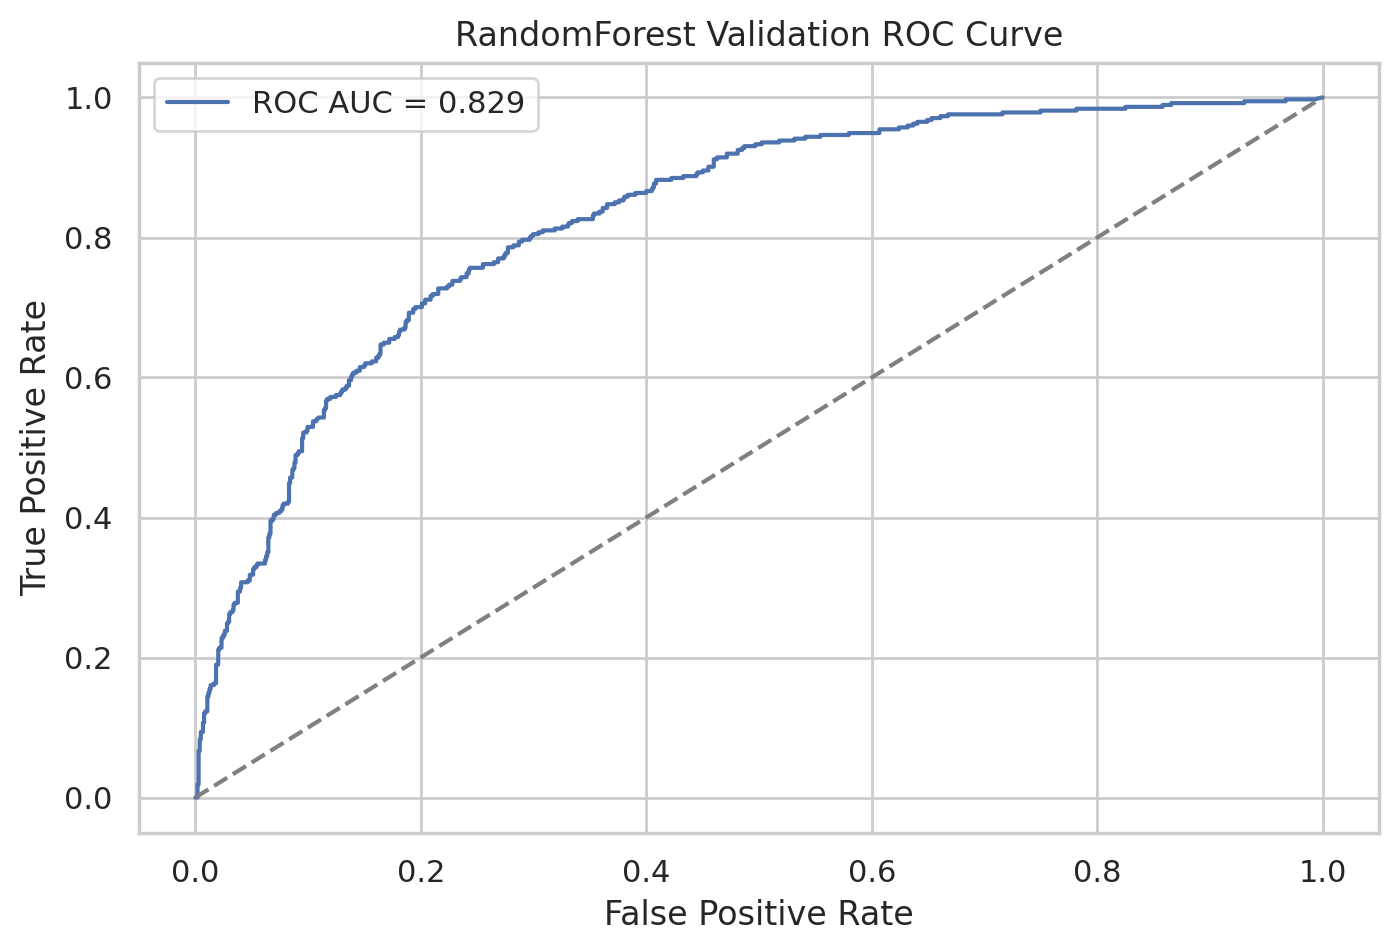

,feature,importance
1,tenure,0.152960
3,totalcharges,0.150327
2,monthlycharges,0.145613
16,contract,0.141717
10,onlinesecurity,0.063927
13,techsupport,0.057156
18,paymentmethod,0.044770
9,internetservice,0.043007
11,onlinebackup,0.031938
17,paperlessbilling,0.023525


In [ ]:
# RandomForest evaluation section: validation metrics only for baseline inspection, plus validation confusion matrix/ROC outputs.
rf_val_probabilities = random_forest_model.predict_proba(X_val_tree)[:, 1]
rf_val_metrics = evaluate_predictions(y_val.to_numpy(), rf_val_probabilities)
display(metrics_to_frame(rf_val_metrics, "validation"))
show_confusion_matrix(y_val.to_numpy(), rf_val_probabilities, title="RandomForest Validation Confusion Matrix")
show_roc_curve(y_val.to_numpy(), rf_val_probabilities, title="RandomForest Validation ROC Curve")

rf_importance = pd.DataFrame({"feature": tree_feature_names, "importance": random_forest_model.feature_importances_}).sort_values("importance", ascending=False).head(15)
display(rf_importance)


## XGBoost Tuning

XGBoost is the main tree-based Assignment 2 model.
We tune it on the validation split with early stopping so we can compare a few realistic configurations while still keeping the workflow understandable and reproducible.


In [ ]:
# Main tree-model tuning section: define XGBoost candidate runs for validation-based selection.
positive_count = int(y_train.sum())
negative_count = int(len(y_train) - positive_count)
scale_pos_weight = negative_count / max(positive_count, 1)

xgb_search_space = [
    {"max_depth": 3, "learning_rate": 0.03, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 1},
    {"max_depth": 4, "learning_rate": 0.05, "subsample": 0.90, "colsample_bytree": 0.90, "min_child_weight": 1},
    {"max_depth": 5, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 3},
    {"max_depth": 4, "learning_rate": 0.08, "subsample": 0.80, "colsample_bytree": 0.90, "min_child_weight": 5},
]
xgb_tuning_rows = []
xgb_trained_models = []
print(f"XGBoost candidate configurations: {len(xgb_search_space)}")


XGBoost candidate configurations: 4


## Why The Validation Set Matters Here

Hyperparameter tuning is model selection.
That means the validation split, not the test split, must drive the choice of configuration; otherwise the final test numbers would be biased and no longer represent a clean holdout evaluation.


In [ ]:
# Tune XGBoost candidates on the training split and rank them on validation metrics only.
EARLY_STOPPING_ROUNDS = 40

for run_id, params in enumerate(xgb_search_space, start=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=1200,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        **params,
    )

    fit_kwargs = {
        "X": X_train_tree,
        "y": y_train,
        "eval_set": [(X_val_tree, y_val)],
        "verbose": False,
    }

    try:
        model.fit(early_stopping_rounds=EARLY_STOPPING_ROUNDS, **fit_kwargs)
    except TypeError:
        try:
            model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
            model.fit(**fit_kwargs)
        except TypeError:
            from xgboost.callback import EarlyStopping

            model.fit(callbacks=[EarlyStopping(rounds=EARLY_STOPPING_ROUNDS, save_best=True)], **fit_kwargs)

    val_probabilities = model.predict_proba(X_val_tree)[:, 1]
    val_metrics = evaluate_predictions(y_val.to_numpy(), val_probabilities)
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None and hasattr(model, "get_booster"):
        booster = model.get_booster()
        best_iteration = getattr(booster, "best_iteration", None)

    xgb_tuning_rows.append({
        "run_id": run_id,
        **params,
        "best_iteration": best_iteration,
        **val_metrics,
    })
    xgb_trained_models.append(model)

xgb_tuning_results = pd.DataFrame(xgb_tuning_rows).sort_values(["roc_auc", "f1"], ascending=False).reset_index(drop=True)
xgb_tuning_results


,run_id,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,best_iteration,accuracy,precision,recall,f1,roc_auc
0,2,4,0.05,0.90,0.90,1,91,0.745209,0.513089,0.786096,0.620908,0.840425
1,3,5,0.05,0.85,0.85,3,102,0.754436,0.525362,0.775401,0.626350,0.839604
2,1,3,0.03,0.85,0.85,1,236,0.745919,0.513841,0.794118,0.623950,0.839424
3,4,4,0.08,0.80,0.90,5,80,0.749468,0.518519,0.786096,0.624867,0.839360


## XGBoost Tuning Results

This table is one of the key Assignment 2 outputs.
It makes the tuning process visible instead of hiding selection behind a single final model, and it shows clearly that model choice is based on validation performance.


In [ ]:
# Select the final XGBoost candidate from validation results before any test reporting.
display(xgb_tuning_results)
best_xgb_run_id = int(xgb_tuning_results.loc[0, "run_id"])
best_xgb_model = xgb_trained_models[best_xgb_run_id - 1]
best_xgb_params = xgb_search_space[best_xgb_run_id - 1]

print("Selected XGBoost configuration based on validation results:")
print(best_xgb_params)


,run_id,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,best_iteration,accuracy,precision,recall,f1,roc_auc
0,2,4,0.05,0.90,0.90,1,91,0.745209,0.513089,0.786096,0.620908,0.840425
1,3,5,0.05,0.85,0.85,3,102,0.754436,0.525362,0.775401,0.626350,0.839604
2,1,3,0.03,0.85,0.85,1,236,0.745919,0.513841,0.794118,0.623950,0.839424
3,4,4,0.08,0.80,0.90,5,80,0.749468,0.518519,0.786096,0.624867,0.839360


Selected XGBoost configuration based on validation results:
{'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 1}


## Final XGBoost Evaluation

Now that the best XGBoost configuration has been selected using the validation split, we can evaluate it professionally on the untouched test split.
Validation is for selection. Test is for final reporting.


,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.745209,0.513089,0.786096,0.620908,0.840425
1,test,0.751597,0.520979,0.796791,0.630021,0.845054


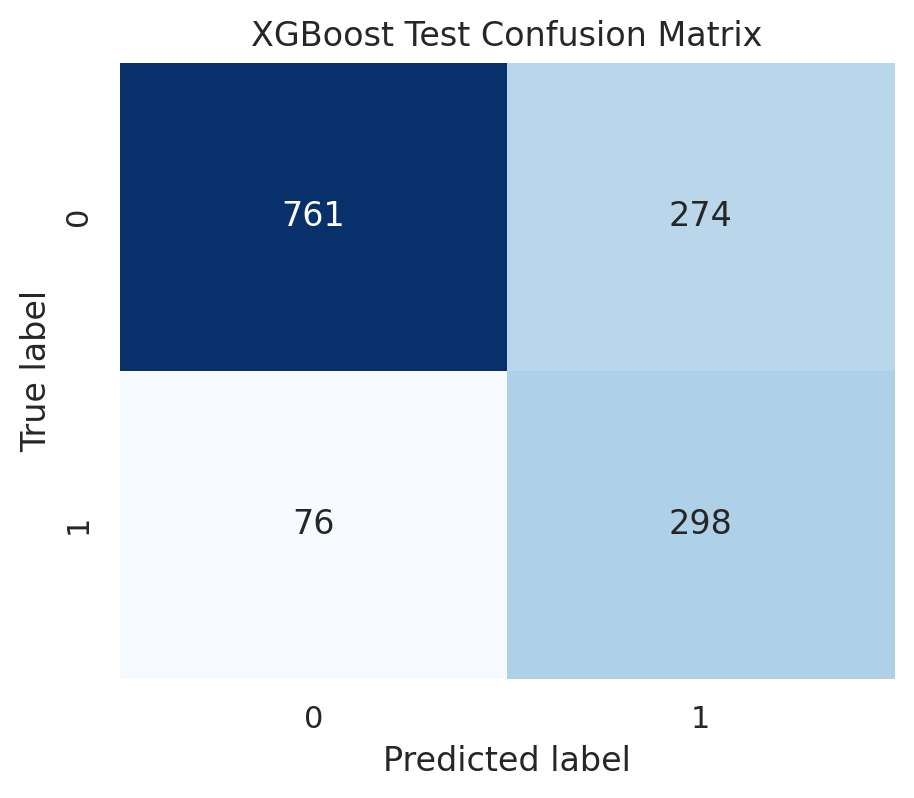

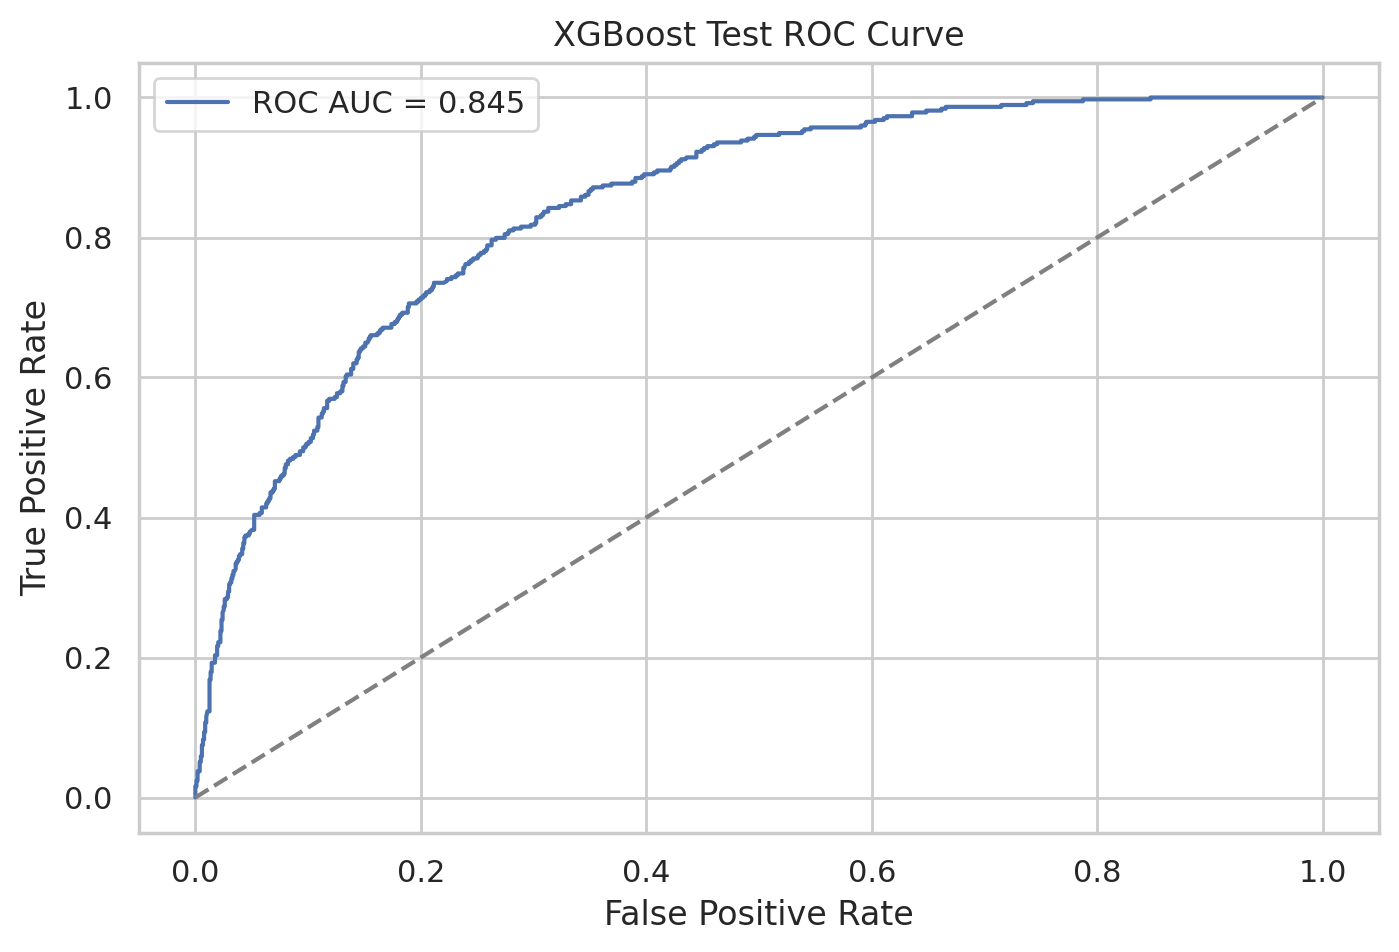

In [ ]:
# XGBoost post-selection evaluation section: validation metrics for the selected model plus final held-out test evaluation.
# Confusion matrix and ROC outputs here belong to the selected model after tuning is complete.
# Evaluate the selected XGBoost model on validation and untouched test splits.
xgb_val_probabilities = best_xgb_model.predict_proba(X_val_tree)[:, 1]
xgb_test_probabilities = best_xgb_model.predict_proba(X_test_tree)[:, 1]

xgb_val_metrics = evaluate_predictions(y_val.to_numpy(), xgb_val_probabilities)
xgb_test_metrics = evaluate_predictions(y_test.to_numpy(), xgb_test_probabilities)

display(pd.concat([
    metrics_to_frame(xgb_val_metrics, "validation"),
    metrics_to_frame(xgb_test_metrics, "test"),
], ignore_index=True))

show_confusion_matrix(y_test.to_numpy(), xgb_test_probabilities, title="XGBoost Test Confusion Matrix")
show_roc_curve(y_test.to_numpy(), xgb_test_probabilities, title="XGBoost Test ROC Curve")


## MLP Preprocessing And Helper Classes

The neural model needs a different input representation from the tree models.
Numeric features are imputed and scaled, while categorical features are converted into integer ids so the model can learn embeddings for them.

We define the remaining MLP-specific helpers first, then fit the neural preprocessing objects on the training split only.


In [ ]:
# Main neural-model preprocessing section: reuse numeric/categorical feature typing for MLP inputs.
# Category maps are built from the training split only and reused for validation/test encoding.
def choose_embedding_dim(cardinality: int) -> int:
    return min(50, max(4, round(1.6 * math.sqrt(cardinality))))


def build_category_maps(frame: pd.DataFrame, categorical_features: list[str]) -> dict[str, dict[str, int]]:
    category_maps = {}
    for feature in categorical_features:
        values = frame[feature].fillna("missing").astype(str)
        unique_values = sorted(values.unique())
        mapping = {"__UNK__": 0}
        for index, value in enumerate(unique_values, start=1):
            mapping[value] = index
        category_maps[feature] = mapping
    return category_maps


def encode_categorical_frame(frame: pd.DataFrame, categorical_features: list[str], category_maps: dict[str, dict[str, int]]) -> np.ndarray:
    encoded_columns = []
    for feature in categorical_features:
        mapping = category_maps[feature]
        values = frame[feature].fillna("missing").astype(str)
        encoded = values.map(lambda item: mapping.get(item, 0)).astype(np.int64).to_numpy()
        encoded_columns.append(encoded)
    if not encoded_columns:
        return np.zeros((len(frame), 0), dtype=np.int64)
    return np.column_stack(encoded_columns)


class TabularDataset(Dataset):
    def __init__(self, categorical_array: np.ndarray, numeric_array: np.ndarray, targets: np.ndarray):
        self.categorical_array = torch.tensor(categorical_array, dtype=torch.long)
        self.numeric_array = torch.tensor(numeric_array, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.targets)

    def __getitem__(self, index: int):
        return self.categorical_array[index], self.numeric_array[index], self.targets[index]


class MLPWithEmbeddings(nn.Module):
    def __init__(self, cardinalities: list[int], numeric_feature_count: int, hidden_dims: list[int], dropout: float):
        super().__init__()
        self.embedding_layers = nn.ModuleList([nn.Embedding(cardinality, choose_embedding_dim(cardinality)) for cardinality in cardinalities])
        embedded_dim = sum(layer.embedding_dim for layer in self.embedding_layers)
        input_dim = embedded_dim + numeric_feature_count

        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(previous_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, categorical_inputs: torch.Tensor, numeric_inputs: torch.Tensor) -> torch.Tensor:
        if len(self.embedding_layers) > 0:
            embedded = [embedding(categorical_inputs[:, index]) for index, embedding in enumerate(self.embedding_layers)]
            embedded = torch.cat(embedded, dim=1)
            combined = torch.cat([embedded, numeric_inputs], dim=1)
        else:
            combined = numeric_inputs
        return self.network(combined).squeeze(1)


def predict_mlp_probabilities(model: nn.Module, categorical_array: np.ndarray, numeric_array: np.ndarray, device: torch.device, batch_size: int = 1024) -> np.ndarray:
    model.eval()
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(categorical_array), batch_size):
            end = start + batch_size
            cat_batch = torch.tensor(categorical_array[start:end], dtype=torch.long, device=device)
            num_batch = torch.tensor(numeric_array[start:end], dtype=torch.float32, device=device)
            logits = model(cat_batch, num_batch)
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probabilities)


def train_mlp_configuration(config: dict, X_train_cat: np.ndarray, X_train_num: np.ndarray, y_train_array: np.ndarray, X_val_cat: np.ndarray, X_val_num: np.ndarray, y_val_array: np.ndarray, cardinalities: list[int], device: torch.device) -> dict:
    train_dataset = TabularDataset(X_train_cat, X_train_num, y_train_array)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    model = MLPWithEmbeddings(cardinalities, X_train_num.shape[1], config["hidden_dims"], config["dropout"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
    loss_function = nn.BCEWithLogitsLoss()

    best_state = deepcopy(model.state_dict())
    best_metrics = None
    best_epoch = 0
    history_rows = []
    patience_counter = 0

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        batch_losses = []
        for categorical_batch, numeric_batch, target_batch in train_loader:
            categorical_batch = categorical_batch.to(device)
            numeric_batch = numeric_batch.to(device)
            target_batch = target_batch.to(device)
            optimizer.zero_grad()
            logits = model(categorical_batch, numeric_batch)
            loss = loss_function(logits, target_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        validation_probabilities = predict_mlp_probabilities(model, X_val_cat, X_val_num, device=device)
        validation_metrics = evaluate_predictions(y_val_array, validation_probabilities)
        history_rows.append({"epoch": epoch, "train_loss": float(np.mean(batch_losses)), **validation_metrics})

        if best_metrics is None or validation_metrics["roc_auc"] > best_metrics["roc_auc"] + 1e-4:
            best_metrics = validation_metrics
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            break

    model.load_state_dict(best_state)
    return {"model": model, "best_metrics": best_metrics, "best_epoch": best_epoch, "history": pd.DataFrame(history_rows), "config": config}


mlp_numeric_imputer = SimpleImputer(strategy="median")
mlp_scaler = StandardScaler()

X_train_num = mlp_numeric_imputer.fit_transform(X_train[numeric_features])
X_val_num = mlp_numeric_imputer.transform(X_val[numeric_features])
X_test_num = mlp_numeric_imputer.transform(X_test[numeric_features])

X_train_num = mlp_scaler.fit_transform(X_train_num)
X_val_num = mlp_scaler.transform(X_val_num)
X_test_num = mlp_scaler.transform(X_test_num)

category_maps = build_category_maps(X_train, categorical_features)
X_train_cat = encode_categorical_frame(X_train, categorical_features, category_maps)
X_val_cat = encode_categorical_frame(X_val, categorical_features, category_maps)
X_test_cat = encode_categorical_frame(X_test, categorical_features, category_maps)

mlp_cardinalities = [max(category_maps[feature].values()) + 1 for feature in categorical_features]
y_train_array = y_train.to_numpy(dtype=np.float32)
y_val_array = y_val.to_numpy(dtype=np.float32)
y_test_array = y_test.to_numpy(dtype=np.float32)

print(f"MLP numeric shape (train): {X_train_num.shape}")
print(f"MLP categorical shape (train): {X_train_cat.shape}")
print(f"Number of embedding tables: {len(mlp_cardinalities)}")


MLP numeric shape (train): (4225, 4)
MLP categorical shape (train): (4225, 15)
Number of embedding tables: 15


## MLP Tuning Strategy

The PyTorch MLP is one of the two main Assignment 2 models, so its tuning must be just as visible as XGBoost tuning.
We compare a small set of realistic configurations by changing hidden dimensions, dropout, learning rate, and batch size.


In [ ]:
# Main neural-model tuning section: define MLP candidate runs with seeded device-aware training.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_search_space = [
    {"hidden_dims": [128, 64], "dropout": 0.10, "learning_rate": 0.0010, "batch_size": 256, "weight_decay": 1e-5, "epochs": 40, "patience": 6},
    {"hidden_dims": [256, 128], "dropout": 0.20, "learning_rate": 0.0010, "batch_size": 256, "weight_decay": 1e-5, "epochs": 40, "patience": 6},
    {"hidden_dims": [128, 64], "dropout": 0.25, "learning_rate": 0.0007, "batch_size": 512, "weight_decay": 1e-4, "epochs": 45, "patience": 7},
    {"hidden_dims": [256, 128, 64], "dropout": 0.20, "learning_rate": 0.0007, "batch_size": 256, "weight_decay": 1e-4, "epochs": 45, "patience": 7},
]
mlp_tuning_results_rows = []
mlp_training_runs = []
print(f"Device for MLP training: {device}")


Device for MLP training: cuda


## MLP Tuning

Just like XGBoost, the MLP must be selected on validation performance rather than intuition.
The next code cell trains multiple candidate configurations, tracks the best validation epoch for each run, and stores a visible results table.


In [ ]:
# Tune MLP candidates on the training split and rank them on validation metrics only.
for run_id, config in enumerate(mlp_search_space, start=1):
    training_result = train_mlp_configuration(
        config=config,
        X_train_cat=X_train_cat,
        X_train_num=X_train_num,
        y_train_array=y_train_array,
        X_val_cat=X_val_cat,
        X_val_num=X_val_num,
        y_val_array=y_val_array,
        cardinalities=mlp_cardinalities,
        device=device,
    )
    mlp_training_runs.append(training_result)
    mlp_tuning_results_rows.append({
        "run_id": run_id,
        "hidden_dims": str(config["hidden_dims"]),
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "weight_decay": config["weight_decay"],
        "best_epoch": training_result["best_epoch"],
        **training_result["best_metrics"],
    })

mlp_tuning_results = pd.DataFrame(mlp_tuning_results_rows).sort_values(["roc_auc", "f1"], ascending=False).reset_index(drop=True)
mlp_tuning_results


,run_id,hidden_dims,dropout,learning_rate,batch_size,weight_decay,best_epoch,accuracy,precision,recall,f1,roc_auc
0,4,"[256, 128, 64]",0.20,0.0007,256,0.00010,10,0.809794,0.696296,0.502674,0.583851,0.839163
1,3,"[128, 64]",0.25,0.0007,512,0.00010,20,0.801987,0.651757,0.545455,0.593886,0.834890
2,1,"[128, 64]",0.10,0.0010,256,0.00001,9,0.797729,0.639498,0.545455,0.588745,0.833552
3,2,"[256, 128]",0.20,0.0010,256,0.00001,5,0.802697,0.661074,0.526738,0.586310,0.833273


## MLP Tuning Results

This table is the neural counterpart to the XGBoost tuning table.
It shows exactly how the MLP candidates performed on the validation split and makes the final neural-model choice transparent.


In [ ]:
# Select the final MLP candidate from validation results before any test reporting.
display(mlp_tuning_results)
best_mlp_run_id = int(mlp_tuning_results.loc[0, "run_id"])
best_mlp_result = mlp_training_runs[best_mlp_run_id - 1]
best_mlp_model = best_mlp_result["model"]
best_mlp_config = best_mlp_result["config"]

print("Selected MLP configuration based on validation results:")
print(best_mlp_config)


,run_id,hidden_dims,dropout,learning_rate,batch_size,weight_decay,best_epoch,accuracy,precision,recall,f1,roc_auc
0,4,"[256, 128, 64]",0.20,0.0007,256,0.00010,10,0.809794,0.696296,0.502674,0.583851,0.839163
1,3,"[128, 64]",0.25,0.0007,512,0.00010,20,0.801987,0.651757,0.545455,0.593886,0.834890
2,1,"[128, 64]",0.10,0.0010,256,0.00001,9,0.797729,0.639498,0.545455,0.588745,0.833552
3,2,"[256, 128]",0.20,0.0010,256,0.00001,5,0.802697,0.661074,0.526738,0.586310,0.833273


Selected MLP configuration based on validation results:
{'hidden_dims': [256, 128, 64], 'dropout': 0.2, 'learning_rate': 0.0007, 'batch_size': 256, 'weight_decay': 0.0001, 'epochs': 45, 'patience': 7}


## Final MLP Evaluation

The MLP has now been selected on the validation split, so we evaluate it on the untouched test split using the same reporting style as XGBoost.
This keeps the final comparison honest and professional.


,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.809794,0.696296,0.502674,0.583851,0.839163
1,test,0.796309,0.653710,0.494652,0.563166,0.839836


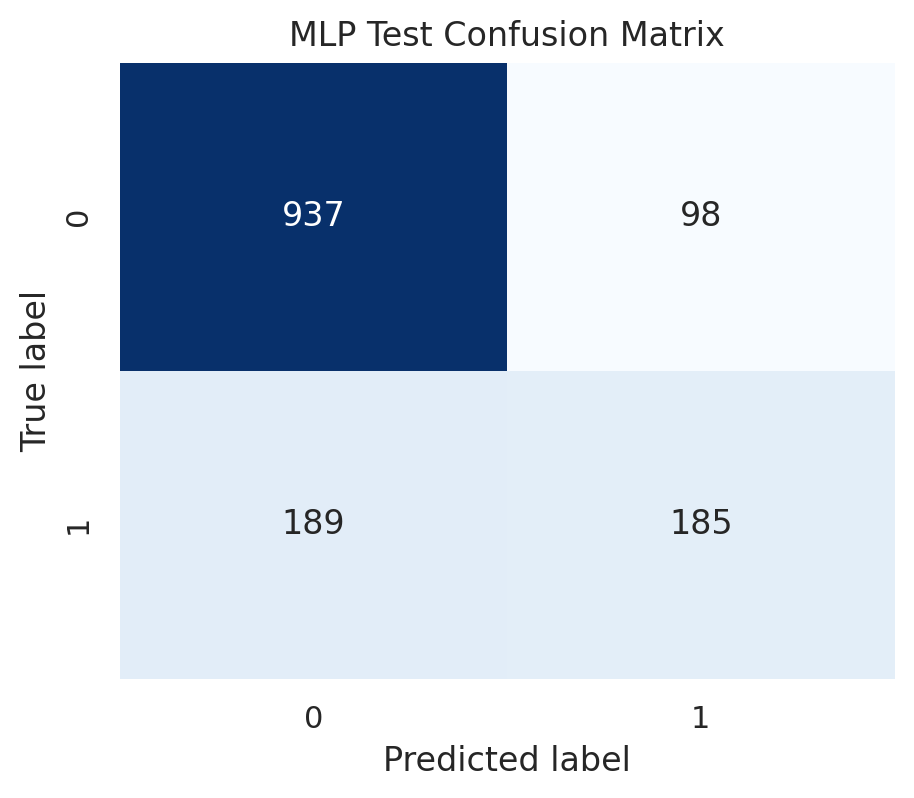

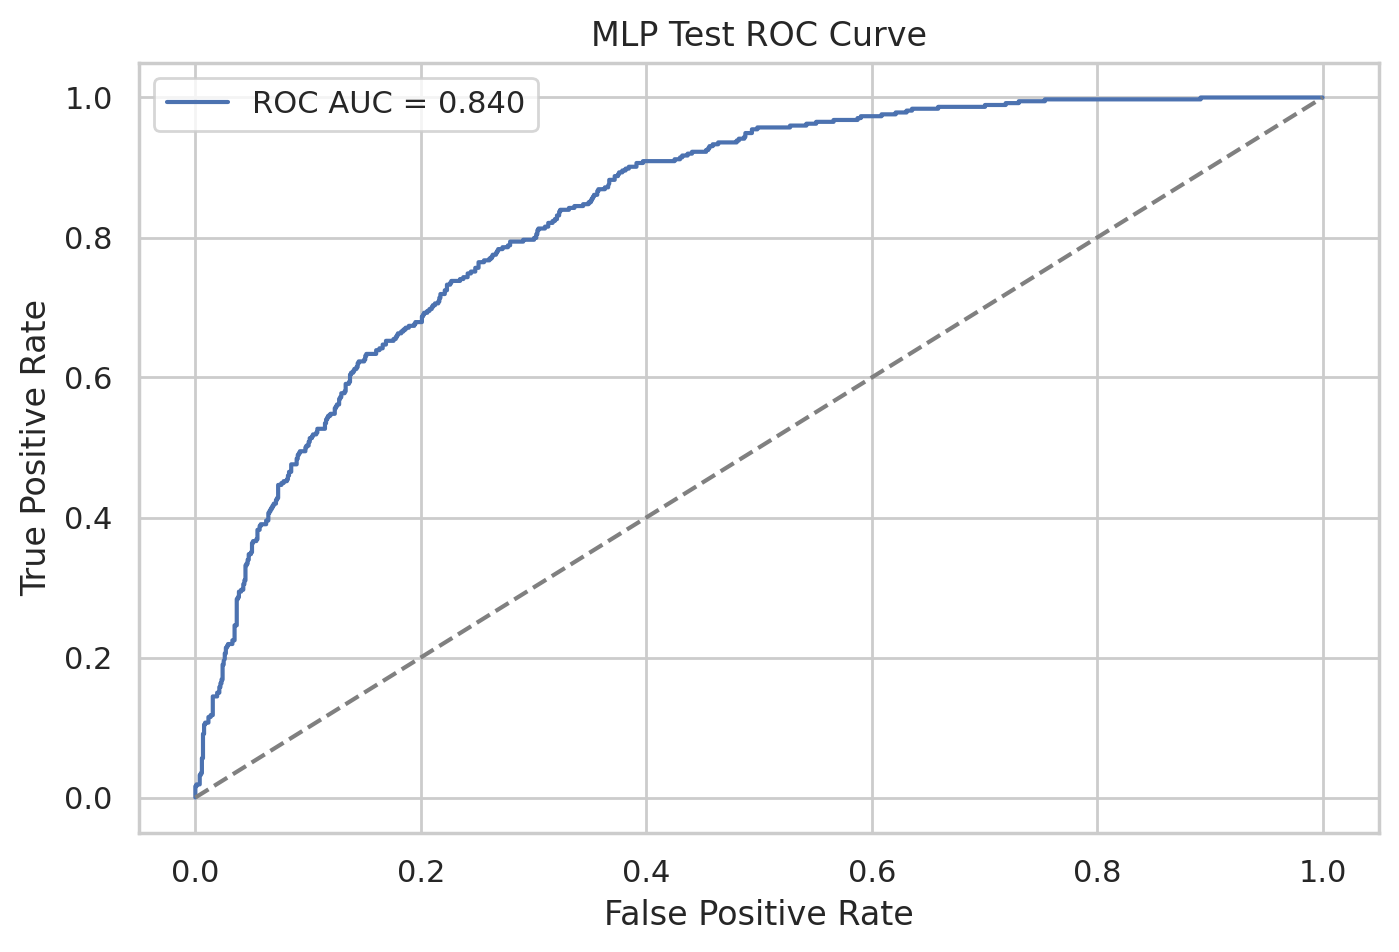

In [ ]:
# MLP post-selection evaluation section: validation metrics for the selected model plus final held-out test evaluation.
# Confusion matrix and ROC outputs here belong to the selected model after tuning is complete.
# Evaluate the selected MLP model on validation and untouched test splits.
mlp_val_probabilities = predict_mlp_probabilities(best_mlp_model, X_val_cat, X_val_num, device=device)
mlp_test_probabilities = predict_mlp_probabilities(best_mlp_model, X_test_cat, X_test_num, device=device)

mlp_val_metrics = evaluate_predictions(y_val_array, mlp_val_probabilities)
mlp_test_metrics = evaluate_predictions(y_test_array, mlp_test_probabilities)

display(pd.concat([
    metrics_to_frame(mlp_val_metrics, "validation"),
    metrics_to_frame(mlp_test_metrics, "test"),
], ignore_index=True))

show_confusion_matrix(y_test_array, mlp_test_probabilities, title="MLP Test Confusion Matrix")
show_roc_curve(y_test_array, mlp_test_probabilities, title="MLP Test ROC Curve")


## Final Comparison Table

This table is the main comparative summary for Assignment 2.
The focus stays on the two main candidate models, **XGBoost** and **the PyTorch MLP**, while **RandomForest** appears only as the baseline row.

The table below reports **test-set metrics** for the selected final models.
Validation metrics were used earlier for tuning and model selection; the test set is used here for final reporting only.


In [ ]:
# Final comparison section: compare all three models after selection using held-out evaluation outputs.
# Final comparison section: compare held-out test metrics after model selection is complete.
rf_test_probabilities = random_forest_model.predict_proba(X_test_tree)[:, 1]
rf_test_metrics = evaluate_predictions(y_test.to_numpy(), rf_test_probabilities)

comparison_table = pd.DataFrame([
    {"model": "XGBoost", "role": "Main tree model", **xgb_test_metrics},
    {"model": "PyTorch MLP", "role": "Main neural model", **mlp_test_metrics},
    {"model": "RandomForest", "role": "Baseline", **rf_test_metrics},
])
display(comparison_table)


,model,role,accuracy,precision,recall,f1,roc_auc
0,XGBoost,Main tree model,0.751597,0.520979,0.796791,0.630021,0.845054
1,PyTorch MLP,Main neural model,0.796309,0.653710,0.494652,0.563166,0.839836
2,RandomForest,Baseline,0.777857,0.578005,0.604278,0.590850,0.832287


## Feature Importance

Model-native feature importance gives us a fast way to see which transformed inputs the final XGBoost model relied on most.
This is not the same as SHAP, but it is still useful as a first importance view.


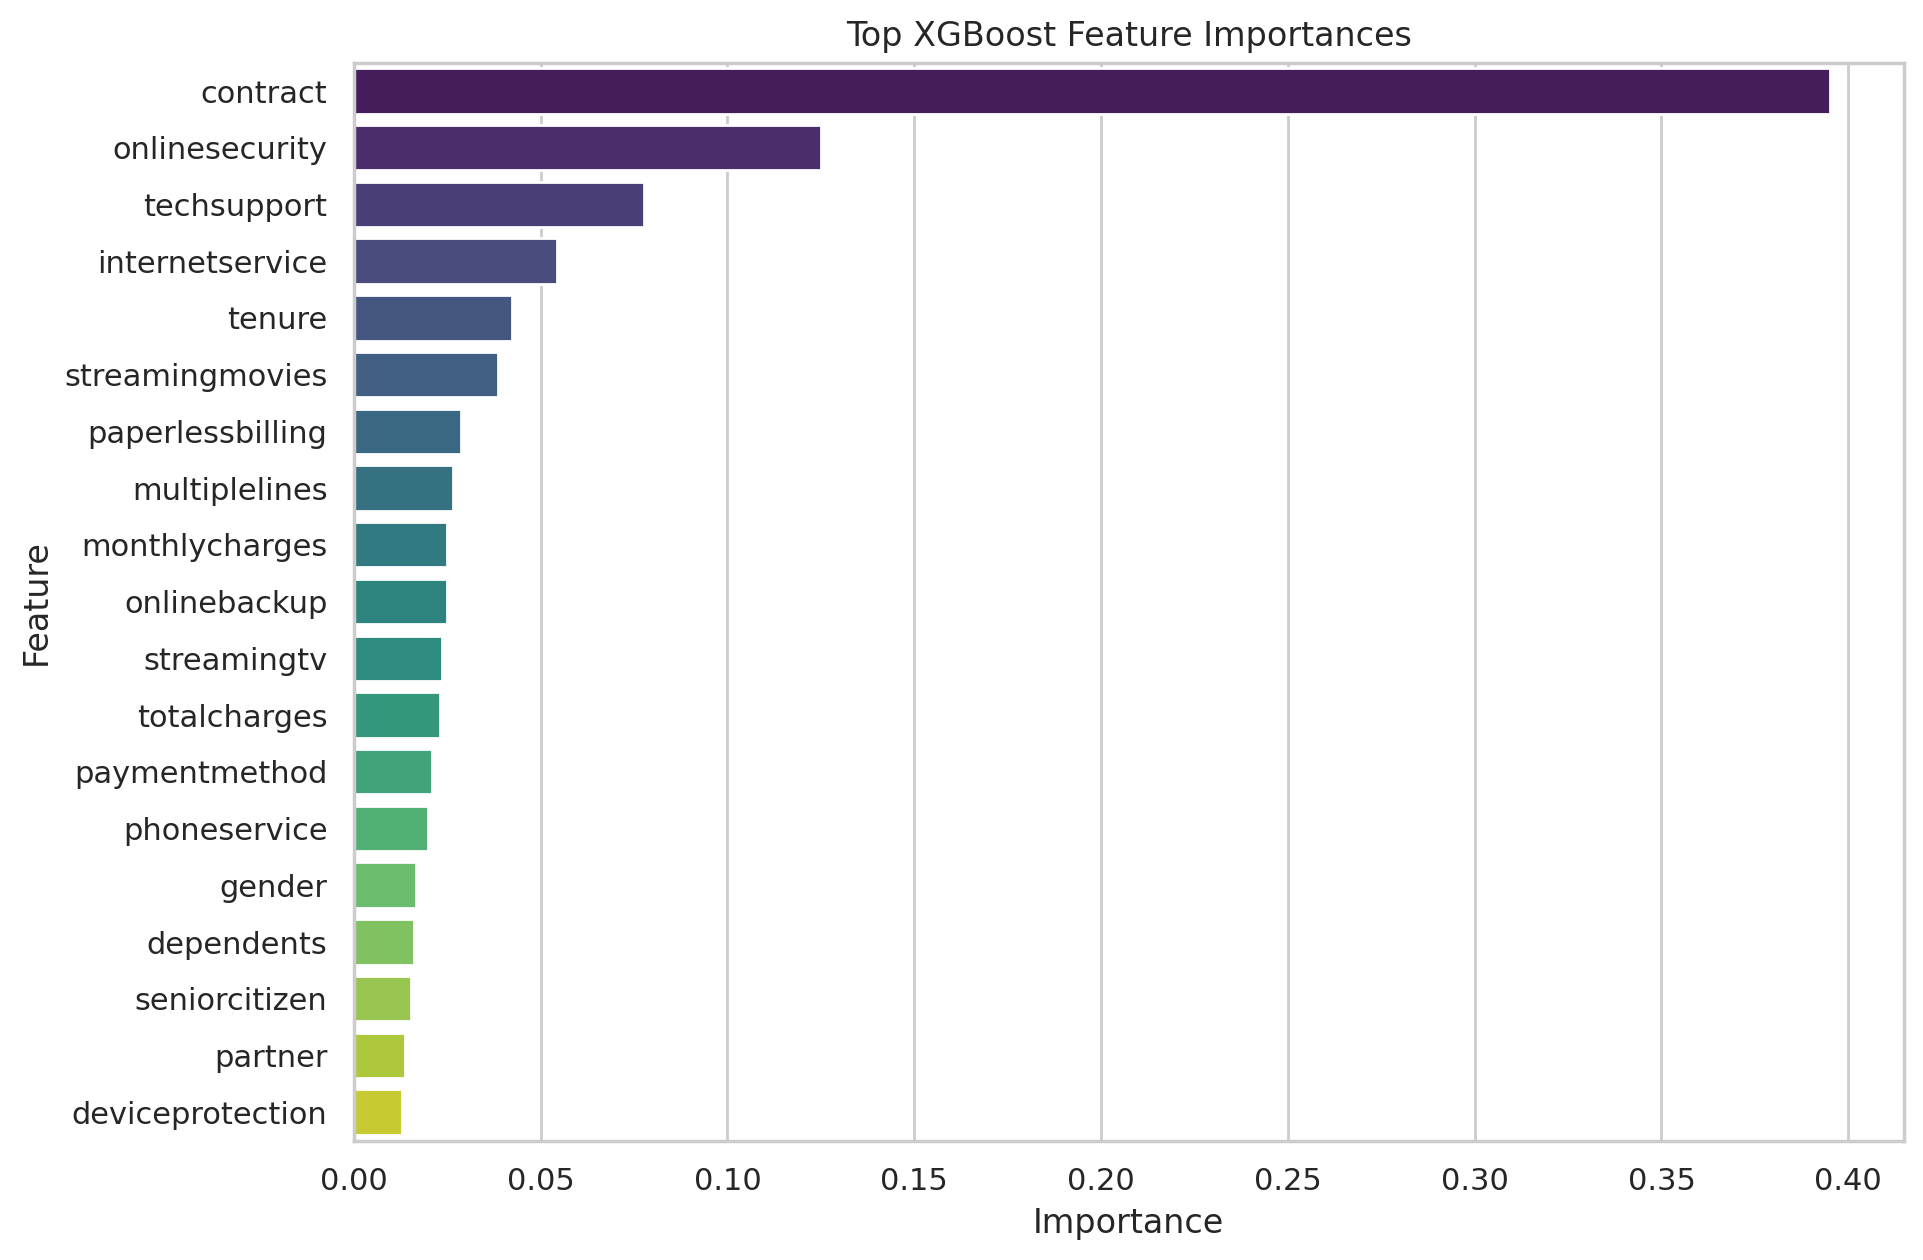

,feature,importance
16,contract,0.395136
10,onlinesecurity,0.124999
13,techsupport,0.077765
9,internetservice,0.054337
1,tenure,0.042346
15,streamingmovies,0.038458
17,paperlessbilling,0.028747
8,multiplelines,0.026441
2,monthlycharges,0.024997
11,onlinebackup,0.024795


In [ ]:
# Feature importance section: tree-based explainability for RandomForest/XGBoost uses tree_feature_names.
xgb_feature_importance = pd.DataFrame({"feature": tree_feature_names, "importance": best_xgb_model.feature_importances_}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=xgb_feature_importance, x="importance", y="feature", palette="viridis")
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(xgb_feature_importance)


## SHAP Summary Plot For The Tree Model

SHAP gives us a more informative explanation than raw feature importance because it shows not only which features matter, but also how feature values push predictions up or down.
For this notebook, SHAP is applied to the final selected XGBoost model because that is the main tree model and the clearest candidate for structured explanation.


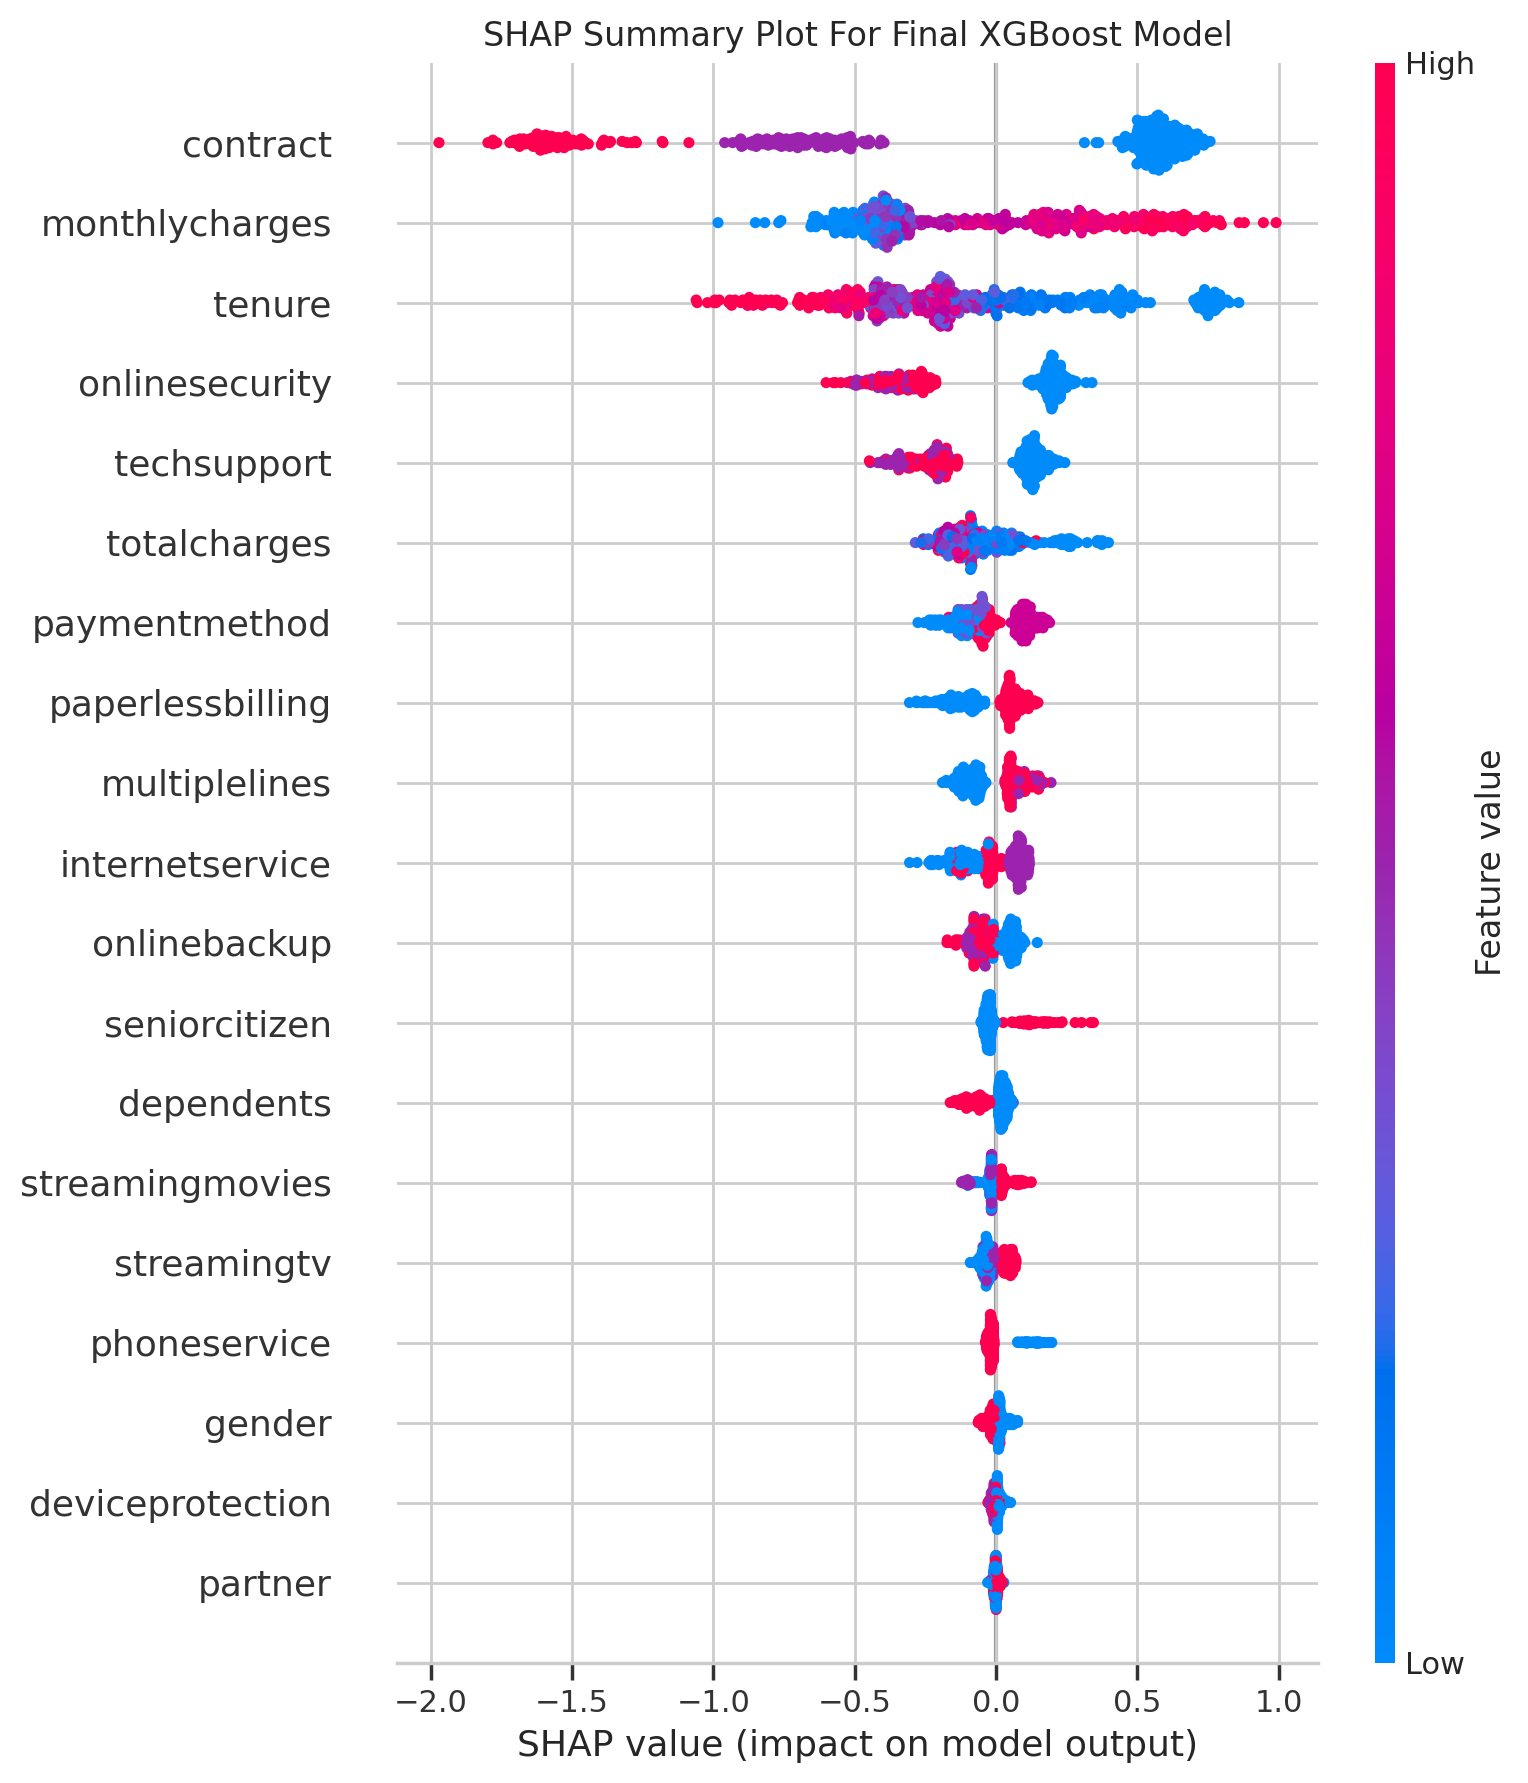

In [ ]:
# SHAP section: explain the selected XGBoost model using tree-preprocessed validation data.
X_val_tree_frame = pd.DataFrame(X_val_tree, columns=tree_feature_names)
shap_sample_size = min(500, len(X_val_tree_frame))
X_val_tree_sample = X_val_tree_frame.sample(n=shap_sample_size, random_state=RANDOM_SEED)

shap_explainer = shap.TreeExplainer(best_xgb_model)
try:
    shap_output = shap_explainer(X_val_tree_sample)
    shap_values = shap_output.values if hasattr(shap_output, "values") else shap_output
except Exception:
    shap_values = shap_explainer.shap_values(X_val_tree_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]
elif shap_values.ndim == 1:
    shap_values = shap_values.reshape(-1, 1)

try:
    shap.summary_plot(shap_values, X_val_tree_sample, show=False)
except Exception:
    shap.summary_plot(shap_values, features=X_val_tree_sample, feature_names=X_val_tree_sample.columns.tolist(), show=False)

plt.title("SHAP Summary Plot For Final XGBoost Model")
plt.tight_layout()
plt.show()


## Export Deployment Artifacts

Once the final models are trained and reviewed, we export the artifacts needed for deployment.
This includes the tree models, the tree preprocessor, the MLP checkpoint, the MLP preprocessing objects, category maps, feature schema, and model metadata.


In [ ]:
# Export section: save the selected models plus shared preprocessing/schema artifacts.
xgb_model_path = EXPORT_DIR / "xgb_model.json"
rf_model_path = EXPORT_DIR / "random_forest.pkl"
tree_preprocessor_path = EXPORT_DIR / "tree_preprocessor.pkl"
mlp_model_path = EXPORT_DIR / "mlp_model.pt"
mlp_preprocessor_path = EXPORT_DIR / "mlp_preprocessor.pkl"
category_maps_path = EXPORT_DIR / "category_maps.json"
feature_schema_path = EXPORT_DIR / "feature_schema.json"
model_metadata_path = EXPORT_DIR / "model_metadata.json"

best_xgb_model.save_model(xgb_model_path)
joblib.dump(random_forest_model, rf_model_path)
joblib.dump(tree_preprocessor, tree_preprocessor_path)

torch.save({
    "model_state_dict": best_mlp_model.state_dict(),
    "cardinalities": mlp_cardinalities,
    "numeric_feature_count": int(X_train_num.shape[1]),
    "hidden_dims": best_mlp_config["hidden_dims"],
    "dropout": best_mlp_config["dropout"],
    "feature_order": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
}, mlp_model_path)

joblib.dump({
    "numeric_imputer": mlp_numeric_imputer,
    "numeric_scaler": mlp_scaler,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
}, mlp_preprocessor_path)

serializable_category_maps = {feature: {key: int(value) for key, value in mapping.items()} for feature, mapping in category_maps.items()}
with open(category_maps_path, "w", encoding="utf-8") as file_handle:
    json.dump(serializable_category_maps, file_handle, indent=2)

feature_schema = {
    "target_column": target_column,
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "drop_columns": drop_columns,
    "tree_feature_names": tree_feature_names,
}
with open(feature_schema_path, "w", encoding="utf-8") as file_handle:
    json.dump(feature_schema, file_handle, indent=2)

model_metadata = {
    "selection_protocol": {
        "training_split": "train",
        "selection_split": "validation",
        "final_reporting_split": "test",
    },
    "baseline_model": {"name": "RandomForestClassifier", "test_metrics": rf_test_metrics},
    "main_tree_model": {
        "name": "XGBoost",
        "validation_metrics": xgb_val_metrics,
        "test_metrics": xgb_test_metrics,
        "best_params": best_xgb_params,
    },
    "main_neural_model": {
        "name": "PyTorch MLP with embeddings",
        "validation_metrics": mlp_val_metrics,
        "test_metrics": mlp_test_metrics,
        "best_config": best_mlp_config,
    },
}
with open(model_metadata_path, "w", encoding="utf-8") as file_handle:
    json.dump(model_metadata, file_handle, indent=2)

print("Artifacts exported:")
for artifact_path in [xgb_model_path, rf_model_path, tree_preprocessor_path, mlp_model_path, mlp_preprocessor_path, category_maps_path, feature_schema_path, model_metadata_path]:
    print(f" - {artifact_path}")


Artifacts exported:
 - exported_artifacts/xgb_model.json
 - exported_artifacts/random_forest.pkl
 - exported_artifacts/tree_preprocessor.pkl
 - exported_artifacts/mlp_model.pt
 - exported_artifacts/mlp_preprocessor.pkl
 - exported_artifacts/category_maps.json
 - exported_artifacts/feature_schema.json
 - exported_artifacts/model_metadata.json


## Summary

This notebook completed the full Assignment 2 modeling workflow.
We explored the dataset, defined preprocessing for each modeling path, tuned XGBoost and the MLP on the validation split, compared the final selected models on the test split, generated feature-importance and SHAP outputs for the tree model, and exported deployment artifacts.


## Optional Professional Addition: Threshold Selection

Threshold tuning can be useful in churn modeling because the default probability threshold of 0.50 is not always aligned with the business tradeoff between false positives and false negatives.
It is marked optional here because Assignment 2 can be completed without it.


In [ ]:
# Optional post-selection analysis uses validation predictions only and does not affect exported artifacts.
primary_model_name = "XGBoost" if xgb_val_metrics["roc_auc"] >= mlp_val_metrics["roc_auc"] else "PyTorch MLP"
primary_validation_probabilities = xgb_val_probabilities if primary_model_name == "XGBoost" else mlp_val_probabilities

threshold_rows = []
for threshold in np.linspace(0.20, 0.80, 13):
    metrics = evaluate_predictions(y_val.to_numpy(), primary_validation_probabilities, threshold=threshold)
    threshold_rows.append({"threshold": round(float(threshold), 2), **metrics})

threshold_table = pd.DataFrame(threshold_rows).sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)
print(f"Optional threshold analysis for: {primary_model_name}")
display(threshold_table.head(10))


Optional threshold analysis for: XGBoost


,threshold,accuracy,precision,recall,f1,roc_auc
0,0.55,0.766501,0.543520,0.751337,0.630752,0.840425
1,0.65,0.801987,0.624672,0.636364,0.630464,0.840425
2,0.60,0.779276,0.569231,0.692513,0.624849,0.840425
3,0.50,0.745209,0.513089,0.786096,0.620908,0.840425
4,0.45,0.722498,0.486443,0.815508,0.609391,0.840425
5,0.40,0.704045,0.468242,0.847594,0.603235,0.840425
6,0.35,0.680625,0.448087,0.877005,0.593128,0.840425
7,0.70,0.800568,0.649518,0.540107,0.589781,0.840425
8,0.30,0.644429,0.420922,0.903743,0.574342,0.840425
9,0.25,0.621008,0.406760,0.933155,0.566558,0.840425


## Optional Professional Addition: Artifact Reload Smoke Test

Exporting files is not enough if they cannot be loaded back cleanly.
This optional step reloads the exported artifacts and runs a tiny smoke test so we can catch serialization mistakes before deployment work starts.


In [ ]:
# Reload check section: verify exported artifacts can be loaded consistently for inference.
reloaded_tree_preprocessor = joblib.load(tree_preprocessor_path)
reloaded_xgb = XGBClassifier()
reloaded_xgb.load_model(xgb_model_path)
reloaded_mlp_checkpoint = torch.load(mlp_model_path, map_location=device)
reloaded_mlp_preprocessor = joblib.load(mlp_preprocessor_path)
with open(category_maps_path, "r", encoding="utf-8") as file_handle:
    reloaded_category_maps = json.load(file_handle)

sample_row = X_test.head(1).copy()
sample_tree_probability = reloaded_xgb.predict_proba(reloaded_tree_preprocessor.transform(sample_row))[:, 1][0]

sample_num = reloaded_mlp_preprocessor["numeric_imputer"].transform(sample_row[numeric_features])
sample_num = reloaded_mlp_preprocessor["numeric_scaler"].transform(sample_num)
sample_cat = encode_categorical_frame(sample_row, categorical_features, reloaded_category_maps)

reloaded_mlp_model = MLPWithEmbeddings(
    cardinalities=reloaded_mlp_checkpoint["cardinalities"],
    numeric_feature_count=reloaded_mlp_checkpoint["numeric_feature_count"],
    hidden_dims=reloaded_mlp_checkpoint["hidden_dims"],
    dropout=reloaded_mlp_checkpoint["dropout"],
).to(device)
reloaded_mlp_model.load_state_dict(reloaded_mlp_checkpoint["model_state_dict"])
reloaded_mlp_probability = predict_mlp_probabilities(reloaded_mlp_model, sample_cat, sample_num, device=device)[0]

print(f"Reloaded XGBoost probability: {sample_tree_probability:.4f}")
print(f"Reloaded MLP probability: {reloaded_mlp_probability:.4f}")


Reloaded XGBoost probability: 0.0624
Reloaded MLP probability: 0.0566


## Optional Professional Addition: MLP Training History

Training-history plots are not strictly required for Assignment 2, but they are helpful when we want to inspect whether the final MLP improved smoothly or showed signs of overfitting.


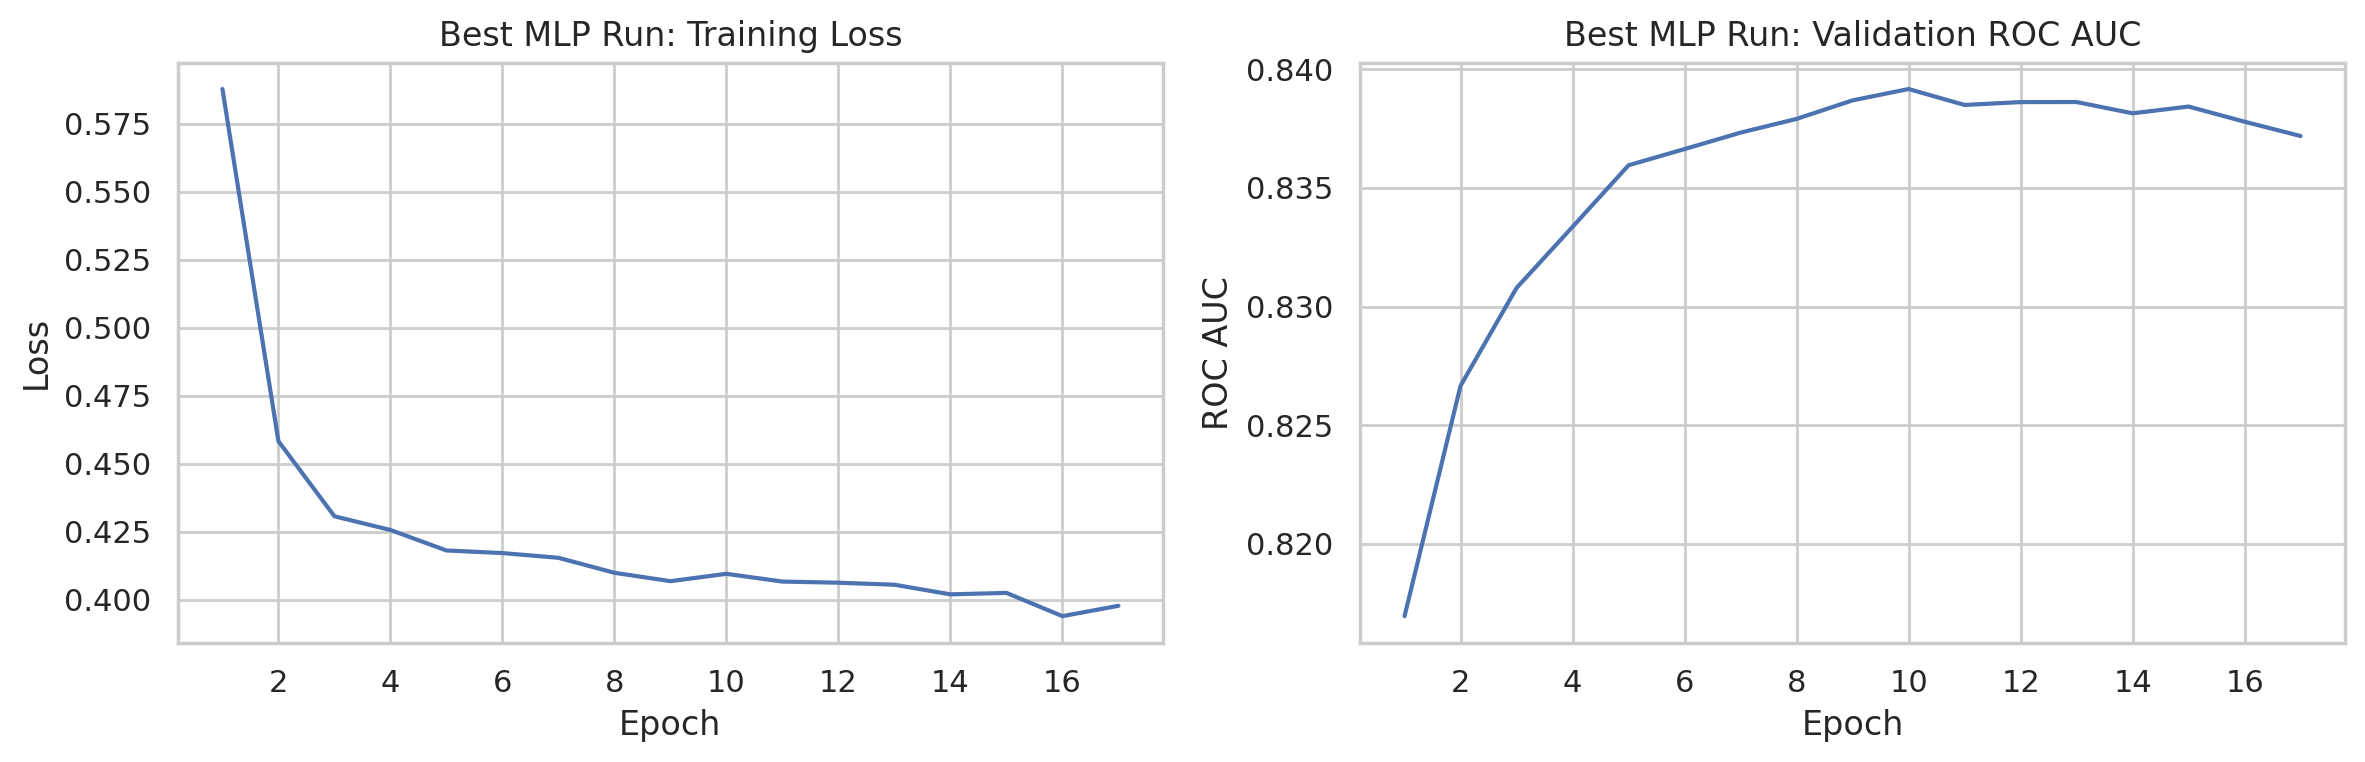

In [ ]:
mlp_history = best_mlp_result["history"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=mlp_history, x="epoch", y="train_loss", ax=axes[0])
axes[0].set_title("Best MLP Run: Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=mlp_history, x="epoch", y="roc_auc", ax=axes[1])
axes[1].set_title("Best MLP Run: Validation ROC AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC AUC")

plt.tight_layout()
plt.show()


In [ ]:
import shutil
import sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

artifact_dir = EXPORT_DIR.resolve()
archive_base = artifact_dir.parent / "exported_artifacts_bundle"
archive_path = shutil.make_archive(str(archive_base), "zip", str(artifact_dir))

print(f"Artifact bundle created at: {archive_path}")

if IS_COLAB:
    try:
        from google.colab import files
        files.download(archive_path)
        print("Download started in Colab.")
    except Exception as error:
        print(f"Colab download step failed: {error}")
else:
    print("Not running in Colab, so automatic browser download was skipped.")
    print(f"You can find the zip file here: {archive_path}")

Artifact bundle created at: /content/exported_artifacts_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in Colab.
